# Main Workflow for Investigating UCRB Drought 1998-2022 <br>
## NOTEBOOK 2: Drought Impacts

The workflow for Nagamoto et al., 2026 for investing UCRB Drought follows 2 main Jupyter Notebooks. The first is for preprocessing raw data, which outputs saved data files that will be used in subsequent notebooks, the second is for running drought impacts code and for plotting.

This is the **second** notebook, for analysis and plotting. Preprocessed data saved from Notebook 1 is loaded and used.

## 1. Load packages and data

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import os
import warnings

# Import custom module
import preprocessing
import calculations
import plotting

# Suppress warnings
warnings.simplefilter('ignore')
%matplotlib inline
print("------ Have loaded all packages ------")

------ Have loaded all packages ------


In [2]:
### Configuration 
var_names   = ['RDC', 'WT', 'SC']
MET_vars    = ['precip', 'temp']
all_variables = ['RDC', 'WT', 'SC','precip', 'temp']
all_vars_qp = ['RDC', 'WT', 'SC','precip', 'temp','runoff_efficiency','reservoirs']
start_year  = 1998
end_year    = 2022
huc         = '14'
prefix      = 'RDC-WT-SC'
start_date  = '1950-01-01'
end_date    = '2022-12-31'
seasons  = ['OND', 'JFM', 'AMJ', 'JAS']
vartypes = ['dr', 'ref', 'relchange']

In [3]:
# load directories and check for OUTPUT directories
dirs = preprocessing.get_dirs()

In [4]:
# load processed data
(gagesii, gage_loc, gagesii_traits, pet_data_df, TRUN_ann_spei_wyears,
 runoff_ann, runoff_efficiency_ann, reservoirs_data, reservoirs_metadata,
 data, meta, avail, met,RMSE_WT_data,PUBS_sites_all3) = preprocessing.load_processed_data(dirs, var_names, MET_vars)

------ loaded GAGESii, PET, SPEI, Runoff, Runoff Efficiency, Reservoirs ------
------ loaded RDC, WT, SC, precip, temp ------


In [5]:
# Prep / normalize q
ready = {}
ready['RDC'] = preprocessing.prep_rdc(data['RDC'], gagesii)
list_all_data = [ready['RDC']]

for var in var_names[1:]:
    ready[var] = data[var].copy()
    list_all_data.append(ready[var])


Normalized streamflow by basin area (m^3 / s km^2)


## 2. Identify Dr and Ref years 
First identify drought and reference years (3yrs pre and post event)

### 2.1 Use SPEI to identify years in 1998-2022

In [6]:
# identify dr and ref years
dr_years,dr_names, list_dr_years, list_ref_years, list_all_years = calculations.identify_years(TRUN_ann_spei_wyears, 
                                                                                               drought_threshold=-1, 
                                                                                               reference_threshold=1, window_size=3)

dr_all3, ref_all3,dr_years_list, sites_all3, refyrs_all3, dryrs_all3 = calculations.build_drought_site_dicts(
    dr_names, list_all_years, list_ref_years, list_dr_years,var_names, list_all_data, avail
)

Identified 6 drought years: [2001, 2002, 2012, 2018, 2020, 2021]
Grouped into 4 drought events: ['2001_2002', '2012', '2018', '2020_2021']
------ created framework of dictionaries for drought, reference, and all years ------


In [7]:
allsites, all3_all_sites, all3vars = calculations.build_site_unions(var_names, dr_names, sites_all3)

Number of sites for each variable across all drought episodes:
RDC: 202
WT: 36
SC: 23
Total unique sites across all variables and episodes: 209
Number of sites with all variables for each drought episode:
2001_2002: 4
2012: 3
2018: 8
2020_2021: 8


### 2.2 Plotting - SPEI and data availability

In [8]:
# IMPORTANT set up plotting for whole notebook - done AFTER drought events identified!
plot_cfg = plotting.setup_plotting(dirs=dirs, dr_names=dr_names)

fig_dir            = plot_cfg['fig_dir']
data_for_figures   = plot_cfg['data_for_figures']
spei_cmap          = plot_cfg['spei_cmap']
episode_cmap       = plot_cfg['episode_cmap']
met_cmap           = plot_cfg['met_cmap']
dark_bwr           = plot_cfg['dark_bwr']
dark_puor          = plot_cfg['dark_puor']
episode_markers    = plot_cfg['episode_markers']
episode_linestyles = plot_cfg['episode_linestyles']
dr_markerstyles    = plot_cfg['dr_markerstyles']
dr_linestyles      = plot_cfg['dr_linestyles']
dr_colors          = plot_cfg['dr_colors']
wmon_names         = plot_cfg['wmon_names']

------ Plotting environment configured ------


In [9]:
### prep data to plot
# SI Fig. S.8 - data availability 
avail_plot = {}
for var in var_names:
    avail_plot[var] = avail[var][allsites[var]].loc[1998:2022]

n = {var: avail_plot[var].shape[1] for var in var_names}

# get the same sites
RDC_sites_in_gages = list(set(gagesii.index.values).intersection(avail_plot['RDC'].columns.values))
gagesii_int = gagesii.transpose()[RDC_sites_in_gages].transpose()


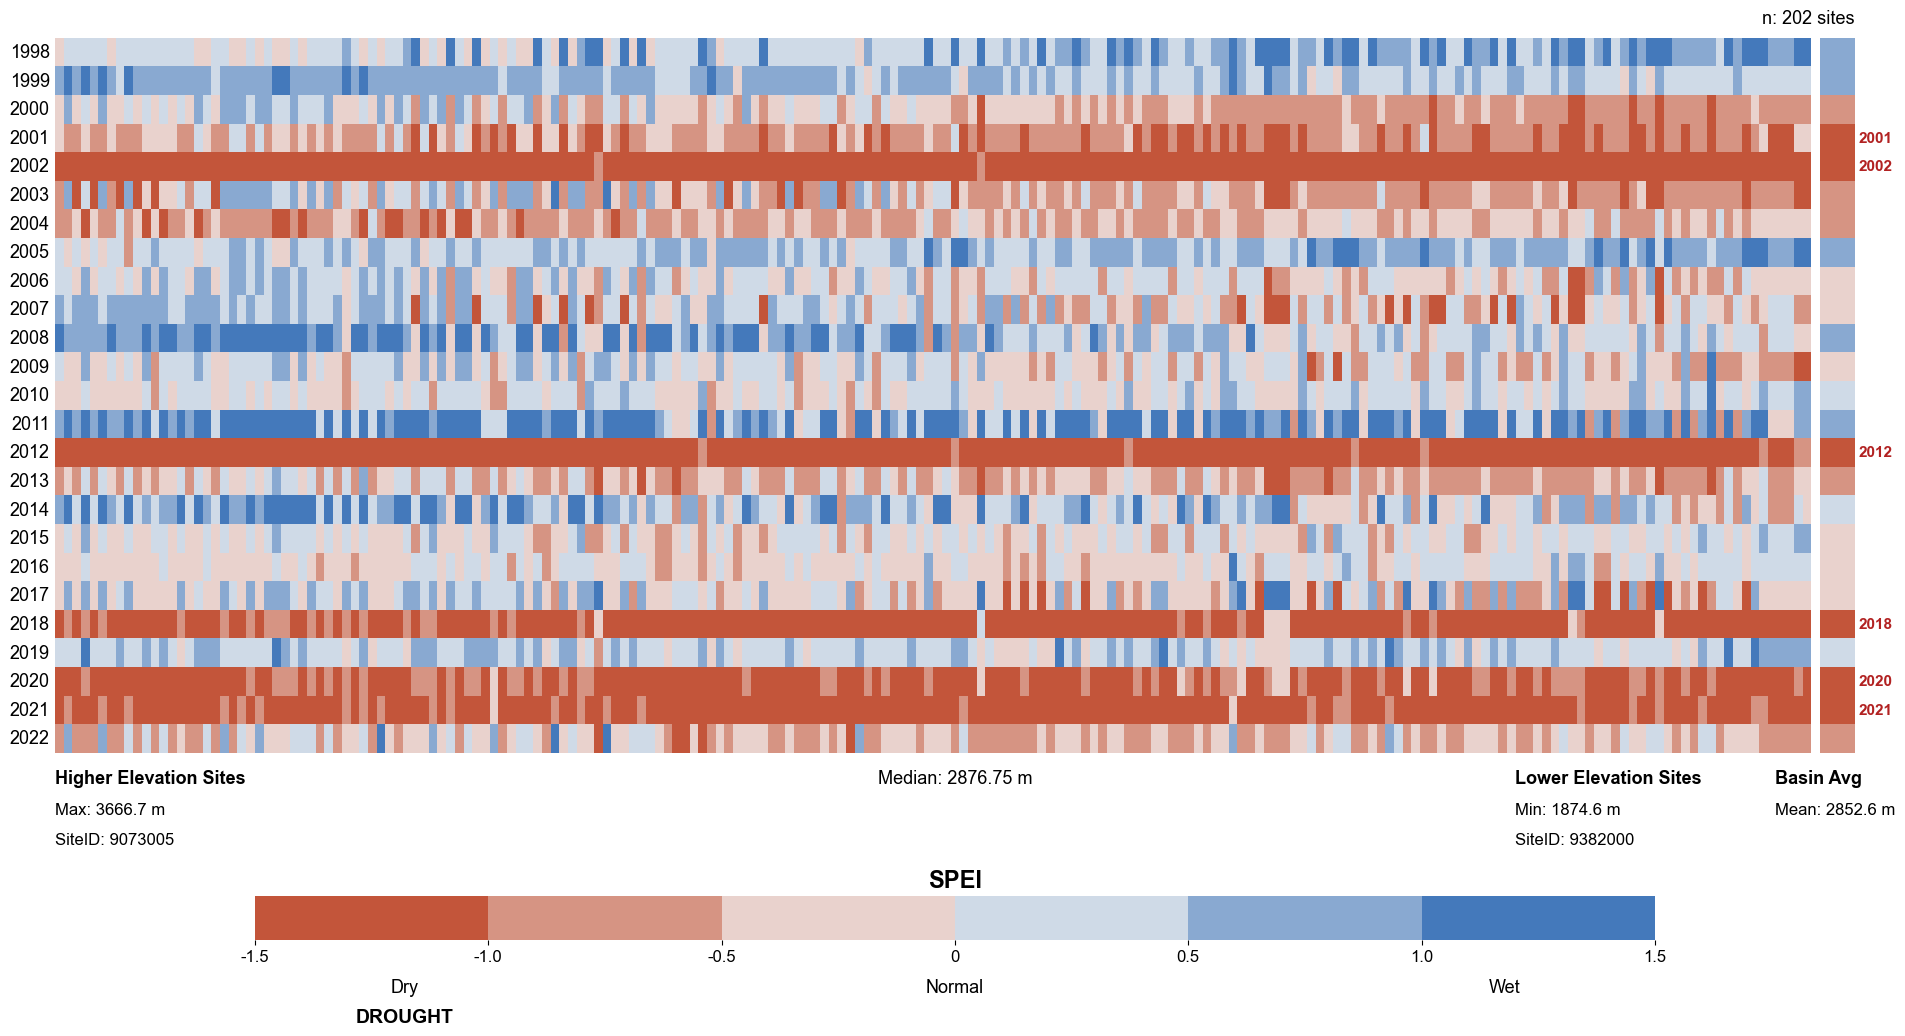

SPEI and elevation dataframe saved: /Users/emilynagamoto/PycharmProjects/drought-impacts-updates/UCRB-drought/OUTPUTS/Figures/spei_ann_wyElevation.csv


In [10]:
# built in save to save the data used to make this figure
plotting.plotting_spei(TRUN_ann_spei_wyears, gagesii_int, RDC_sites_in_gages,spei_cmap,figure_dir= fig_dir, OPTION=True)

Saved figures to /Users/emilynagamoto/PycharmProjects/drought-impacts-updates/UCRB-drought/OUTPUTS/Figures/


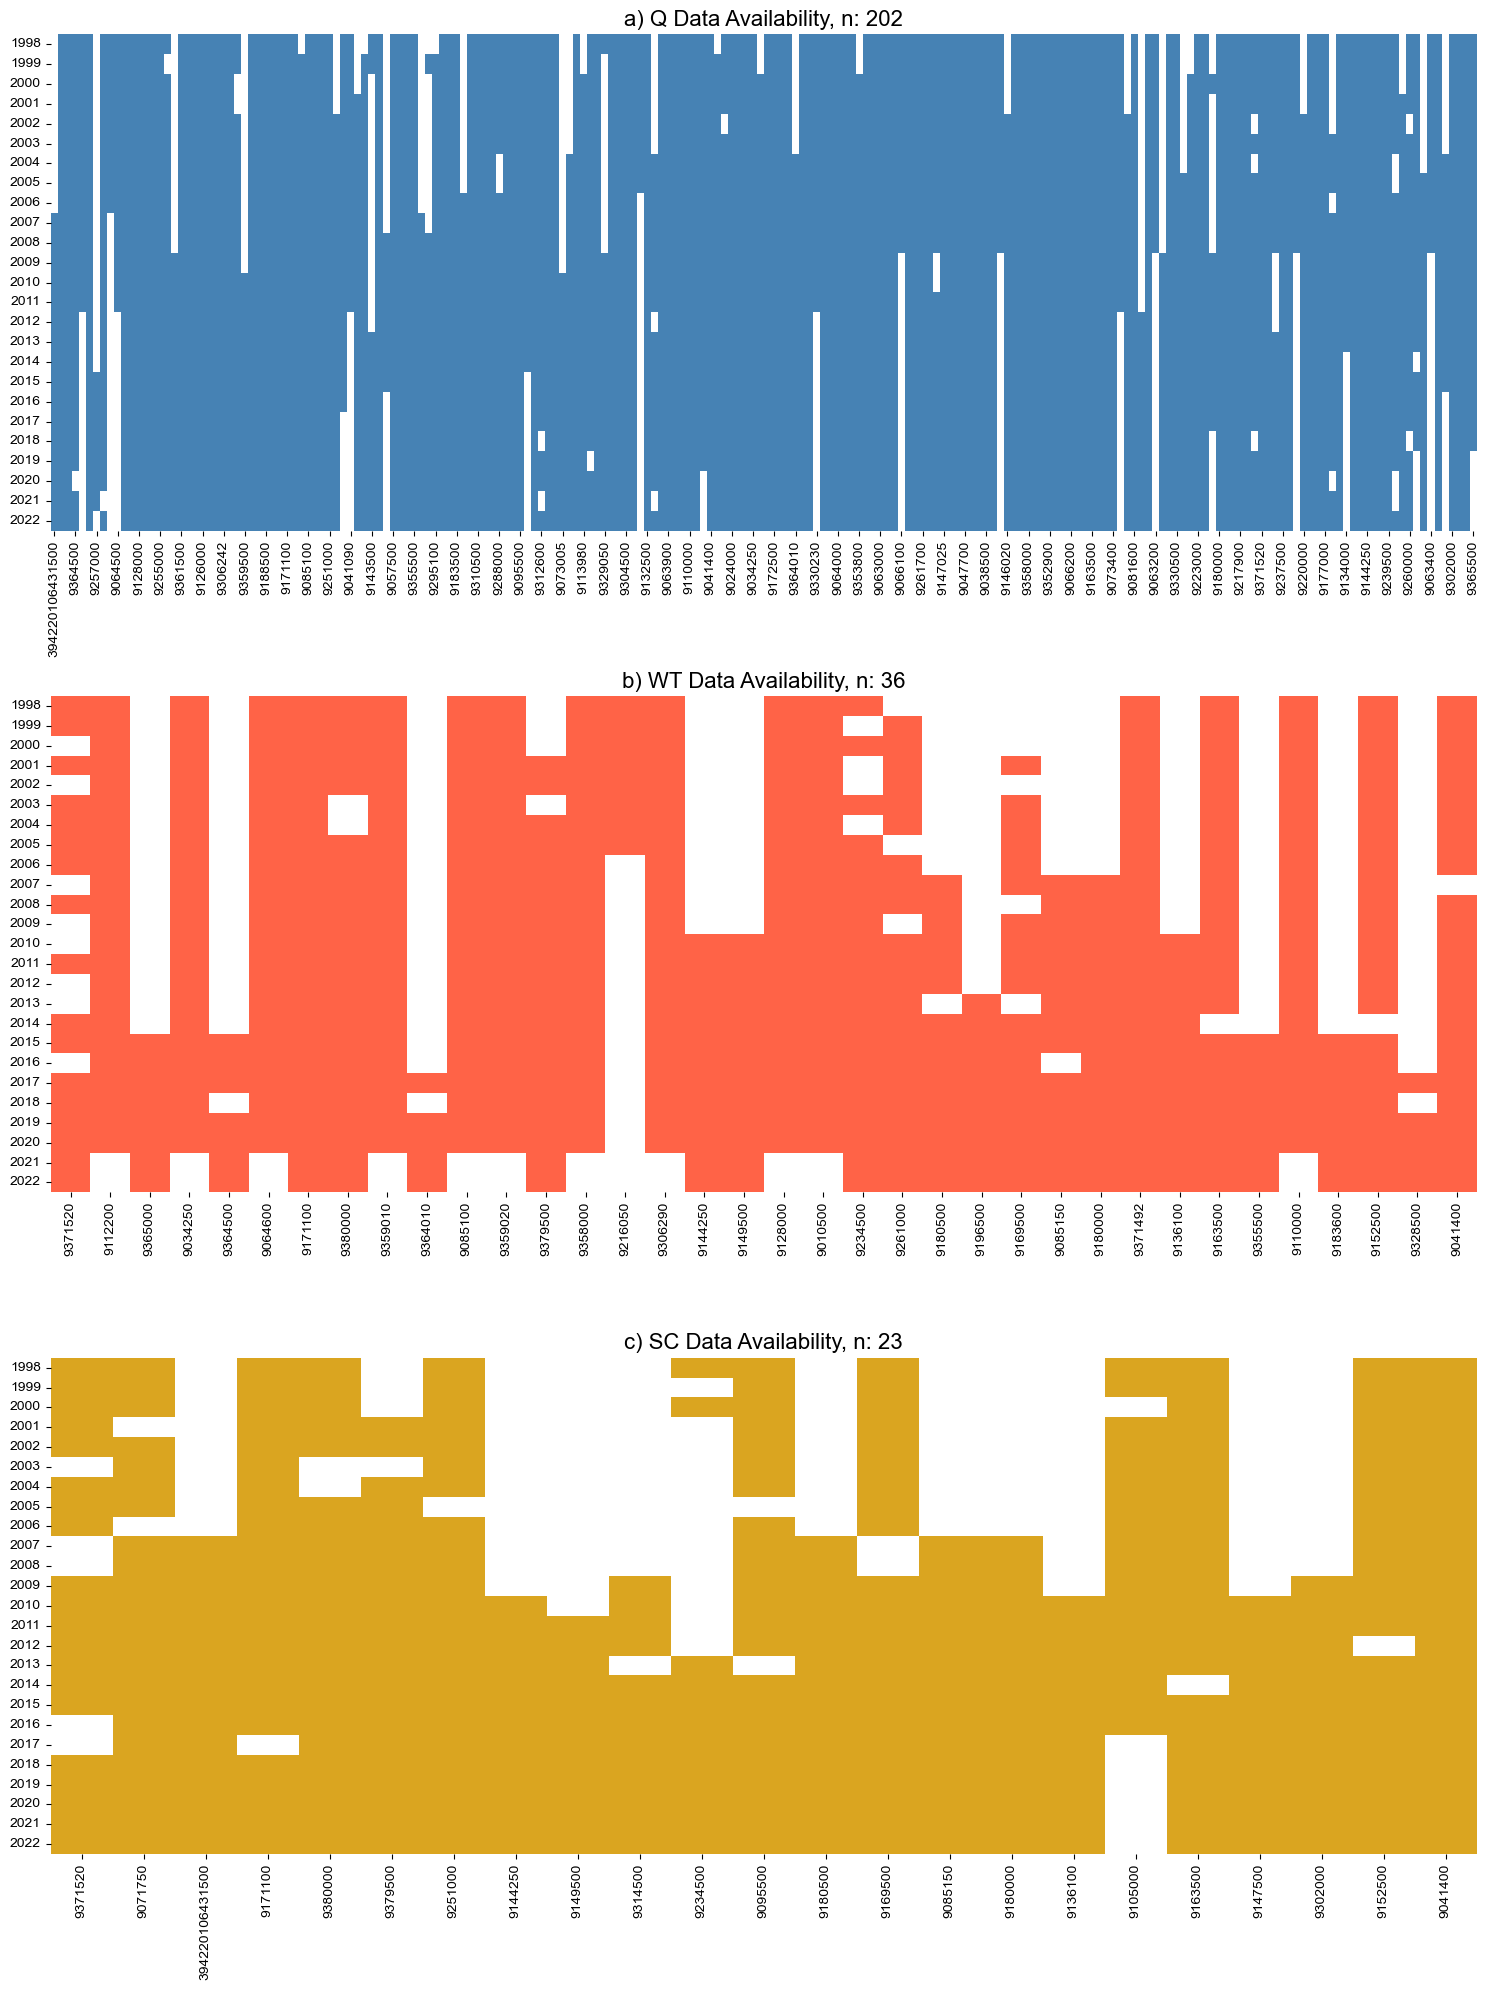

In [11]:
# plot data availability - SI Fig S.8
fig, axes = plotting.plot_data_availability(
    avail_plot    = avail_plot,
    n             = n,
    episode_cmap  = {var: c for var, c in zip([0,1,2], ['steelblue', 'tomato', 'goldenrod'])},
    fig_dir       = fig_dir,
    save          = True
)

In [12]:
# save data that made the plots
# SPEI data already saved

# SI Fig. S.8 - data availability 
for var in var_names:
    avail[var][allsites[var]].loc[1998:2022].to_csv(data_for_figures + f'{var}_avail_df.csv')


## 3. Calculate Relative Change

### 3.1 Median Relative Change - RDC, WT, SC
Use Eq 1 from the manuscript to calculate relative change

In [13]:
longtermavg, basin_avg = calculations.calculate_longterm_avg(ready, allsites, var_names)

In [14]:
# RDC, WT, SC
ann_MED, mon_MED = calculations.calculate_rel_change_all(
    var_list      = var_names,
    dr_names      = dr_names,
    ref_all3      = ref_all3,
    dr_years      = dr_years,
    refyrs_all3   = refyrs_all3,
    dryrs_all3    = dryrs_all3,
    use_presliced = True
)

# RDC, WT, SC
MED_allsites, MED_all3 = calculations.aggregate_episodes(
    var_list       = var_names,
    dr_names       = dr_names,
    ann_MED        = ann_MED,
    include_dr_ref = True
)

------ calculated annual and monthly median relative change for ['RDC', 'WT', 'SC']  ------
Median Annual Relative Change: RDC [-14.55344018]
Median Annual DR:              RDC [0.00213904]
Median Annual Ref:             RDC [0.00259276]
Median Annual Relative Change: WT [8.54118619]
Median Annual DR:              WT [9.759375]
Median Annual Ref:             WT [9.1375]
Median Annual Relative Change: SC [5.38492902]
Median Annual DR:              SC [961.41666667]
Median Annual Ref:             SC [852.75]


In [15]:
# RDC, WT, SC
yespriorSept = False
seasonMED, seasonMED_all, allep_seasonal, allep_combined = calculations.calculate_seasonal_rel_change(
    var_list       = var_names,
    dr_names       = dr_names,
    dr_years       = dr_years_list,
    ref_all3       = ref_all3,
    seasons        = seasons,
    vartypes       = vartypes,
    site_index_dict = allsites,
    yespriorSept   = yespriorSept,
    sites_all3     = sites_all3,
    use_presliced  = True
)

RDC Median SEASONAL Relative Change:
            dr       ref  relchange
OND  0.002136  0.002085   3.909762
JFM  0.001589  0.001692  -2.920123
AMJ  0.006494  0.011364 -36.910920
JAS  0.002541  0.003812 -40.642068
WT Median SEASONAL Relative Change:
             dr        ref  relchange
OND   4.696875   5.418750   9.361660
JFM   2.597772   2.634308   2.469061
AMJ  12.587500  10.187500  19.001206
JAS  18.425000  17.498968   4.730018
SC Median SEASONAL Relative Change:
              dr         ref  relchange
OND  982.500000  987.166667  -5.254521
JFM  998.833333  912.062500   0.029452
AMJ  695.583333  502.666667  42.171134
JAS  937.250000  754.000000  16.976541


### 3.2 Median Rel Change - Precip, Air Temp

In [16]:
# Convert MET to water years
met_wyear, list_met_wyears = preprocessing.prep_met_water_years(met, MET_vars, gagesii)

# Flatten drought years across all episodes
all_dr_years_flat = [yr for episode in list_dr_years for yr in episode]

MET_sites_all3, MET_refyrs_all3, MET_dryrs_all3 = calculations.build_site_dicts_no_filter(
            ref_all3, dr_names, list_all_years, list_ref_years, list_dr_years,
            MET_vars, list_met_wyears
        )
# Calculate climatology and get congruent sites
basin_avg_met, congruent_sites, met_avg_list = calculations.calculate_meteorological_climatology(
    list_met_wyears, all3_all_sites, all_dr_years_flat, start_year
)

# Merge MET basin averages into existing basin_avg dict
basin_avg.update(basin_avg_met)

# Per-episode met averages
met_avg = {MET: {} for MET in MET_vars}
for MET in MET_vars:
    for num, dr in enumerate(dr_names):
        met_avg[MET][dr] = met_avg_list[MET][num]


------ created site dictionaries (no availability filtering) ------


In [17]:
# precip, temp
met_ann_MED, met_mon_MED = calculations.calculate_rel_change_all(
    var_list      = MET_vars,
    dr_names      = dr_names,
    ref_all3      = ref_all3,
    dr_years      = dr_years_list,
    data_dict     = congruent_sites,
    use_presliced = False
)

# precip, temp
met_MED_allsites, met_MED_all3 = calculations.aggregate_episodes(
    var_list       = MET_vars,
    dr_names       = dr_names,
    ann_MED        = met_ann_MED,
    include_dr_ref = False
)

------ calculated annual and monthly median relative change for ['precip', 'temp']  ------
Median Annual Relative Change: precip -23.091449970292423
Median Annual Relative Change: temp 24.843321769357964


In [18]:
# precip, temp
met_site_index = {MET: congruent_sites[MET].columns for MET in MET_vars}

met_seasonMED, met_seasonMED_all, met_allep_seasonal, met_allep_combined = calculations.calculate_seasonal_rel_change(
    var_list        = MET_vars,
    dr_names        = dr_names,
    dr_years        = dr_years_list,
    ref_all3        = ref_all3,
    seasons         = seasons,
    vartypes        = vartypes,
    site_index_dict = met_site_index,
    yespriorSept    = yespriorSept,
    sites_all3      = MET_sites_all3,
    use_presliced   = True
)


precip Median SEASONAL Relative Change:
             dr        ref  relchange
OND  46.482435  56.809629 -17.465767
JFM  51.212683  59.114198 -14.460111
AMJ  27.756366  58.115786 -49.939214
JAS  38.726147  48.311512 -22.937812
temp Median SEASONAL Relative Change:
             dr        ref  relchange
OND  -1.898555  -1.772188 -47.643365
JFM  -6.307045  -5.372471 -17.885867
AMJ   7.707062   5.678446  34.349224
JAS  14.504272  13.930631   4.865223


In [19]:
# Load annual and monthly median drought and reference data
ann_MED_drought = {var: {} for var in var_names}
ann_MED_ref     = {var: {} for var in var_names}
ann_MED_relchange     = {var: {} for var in var_names}

mon_MED_drought   = {var: {} for var in all_variables}
mon_MED_relchange = {var: {} for var in all_variables}
mon_MED_ref = {var: {} for var in all_variables}

for var in var_names:
    for dr in dr_names:
        ann_MED_drought[var][dr] = ann_MED[var][dr]['drought'].squeeze()
        ann_MED_ref[var][dr]     = ann_MED[var][dr]['ref'].squeeze()
        ann_MED_relchange[var][dr] = ann_MED[var][dr]['relchange'].squeeze()

        mon_MED_drought[var][dr] = mon_MED[var][dr]['drought'].squeeze()
        mon_MED_ref[var][dr] = mon_MED[var][dr]['ref'].squeeze()
        mon_MED_relchange[var][dr]     = mon_MED[var][dr]['relchange'].squeeze()

for MET in MET_vars:
    for dr in dr_names:
        mon_MED_drought[MET][dr]   = met_mon_MED[MET][dr]['drought'].squeeze()
        mon_MED_ref[MET][dr]   = met_mon_MED[MET][dr]['ref'].squeeze()
        mon_MED_relchange[MET][dr] = met_mon_MED[MET][dr]['relchange'].squeeze()


### 3.3 Rel Change - Runoff Efficiency

In [20]:
# ann_MED_RE = {var: {} for var in ['RE']}

# for dr in dr_names:
#     ann_MED_RE['RE'][dr] = {}
#     df_ref = runoff_efficiency_ann[runoff_efficiency_ann.index.get_level_values('wyear').isin(ref_all3[dr])][sites_all3['RDC'][dr].columns]
#     df_dr  = runoff_efficiency_ann[runoff_efficiency_ann.index.get_level_values('wyear').isin(dr_years_list[dr])][sites_all3['RDC'][dr].columns]
#     (ann_MED_RE['RE'][dr]['relchange'],ann_MED_RE['RE'][dr]['drought'],ann_MED_RE['RE'][dr]['ref'],ann_MED_RE['RE'][dr]['diff'] ) = rel_change_median_annual(df_ref, df_dr, dr)


In [21]:
# RE
ann_MED_RE, sites_all3_RE, avail_RE = calculations.calc_values_RE(
    dr_names      = dr_names,
    ref_all3      = ref_all3,
    dr_all3       = dr_all3,
    dr_years      = dr_years_list,
    data     = runoff_efficiency_ann,
    site_2_use = sites_all3['RDC'],
    available = avail['RDC'],
)

# RE
MED_allsites_RE, MED_all3_RE = calculations.aggregate_episodes(
    var_list       = ['RE'],
    dr_names       = dr_names,
    ann_MED        = ann_MED_RE,
    include_dr_ref = True
)



Median Annual Relative Change: RE [-20.39519523]
Median Annual DR:              RE [0.23822851]
Median Annual Ref:             RE [0.32191955]


### 3.4 Plotting

#### Ann Dr vs Ref comparison - SI Fig S.1

Saved figures to /Users/emilynagamoto/PycharmProjects/drought-impacts-updates/UCRB-drought/OUTPUTS/Figures/


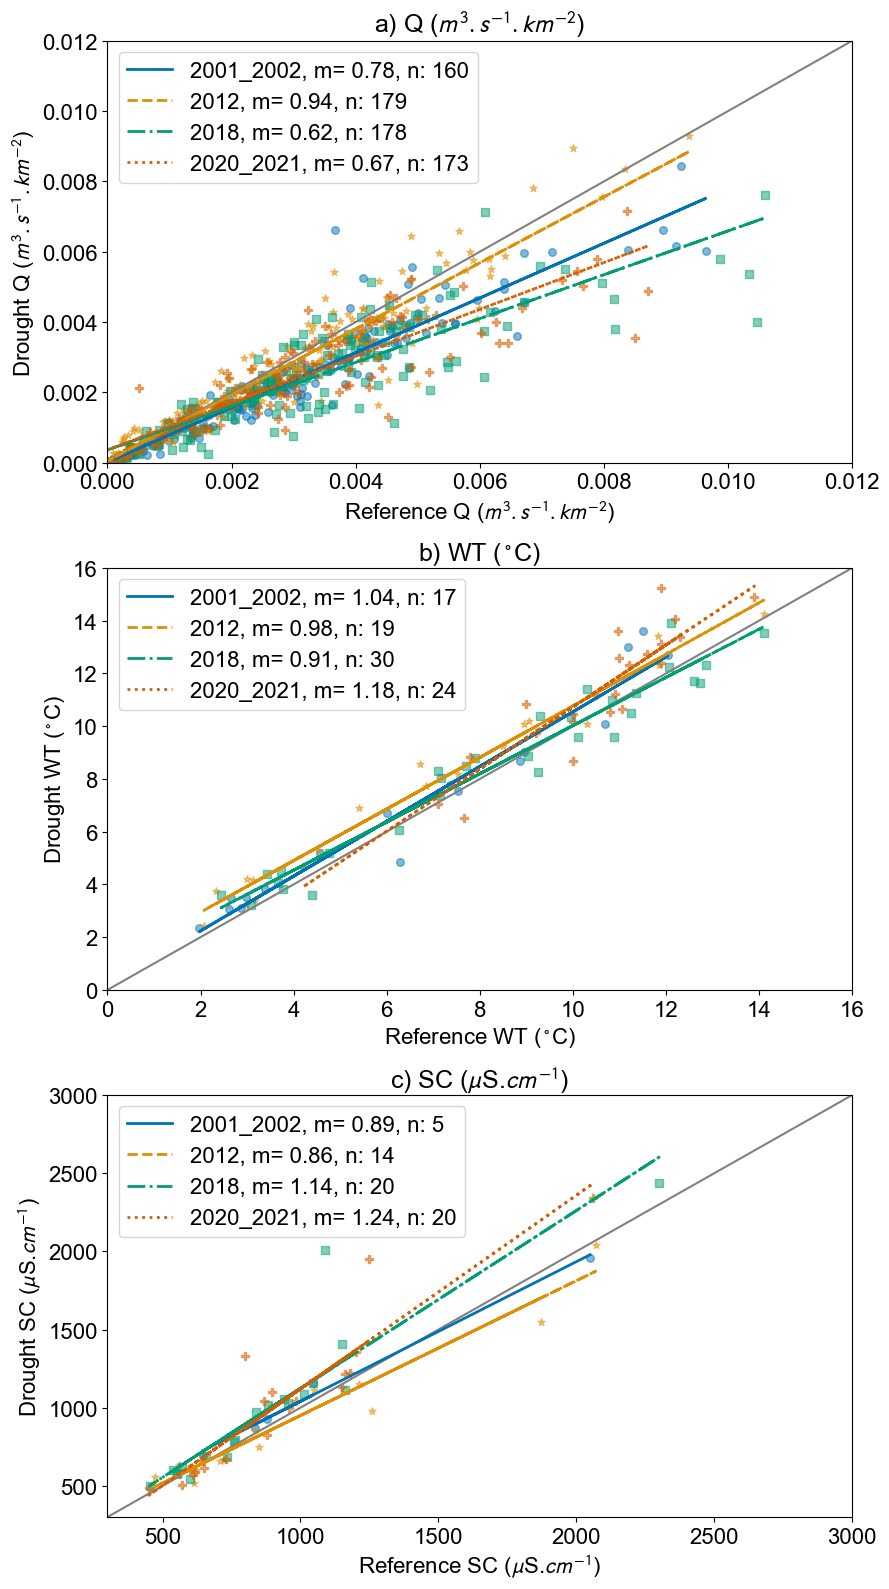

In [21]:
var_plot_names = {
    'RDC': (r'Q ($m^{3}.s^{-1}.km^{-2}$)', 'a)', (0, 0.012), (0, 0.012), (0, 0)),
    'WT':  (r'WT ($^\circ$C)',              'b)', (0, 16),    (0, 16),    (4, 4)),
    'SC':  (r'SC ($\mu$S.$cm^{-1}$)',       'c)', (300, 3000),(300, 3000),(400, 400)),
}

fig, axes = plotting.plot_dr_ref_scatter(
    var_names         = var_names,
    dr_names          = dr_names,
    ann_MED_drought   = ann_MED_drought,
    ann_MED_ref       = ann_MED_ref,
    episode_cmap      = episode_cmap,
    episode_markers   = episode_markers,
    episode_linestyles= episode_linestyles,
    var_plot_names    = var_plot_names,
    fig_dir           = fig_dir,
    save              = True
)

#### Monthly VARS and MET rel change

Saved figures to /Users/emilynagamoto/PycharmProjects/drought-impacts-updates/UCRB-drought/OUTPUTS/Figures/


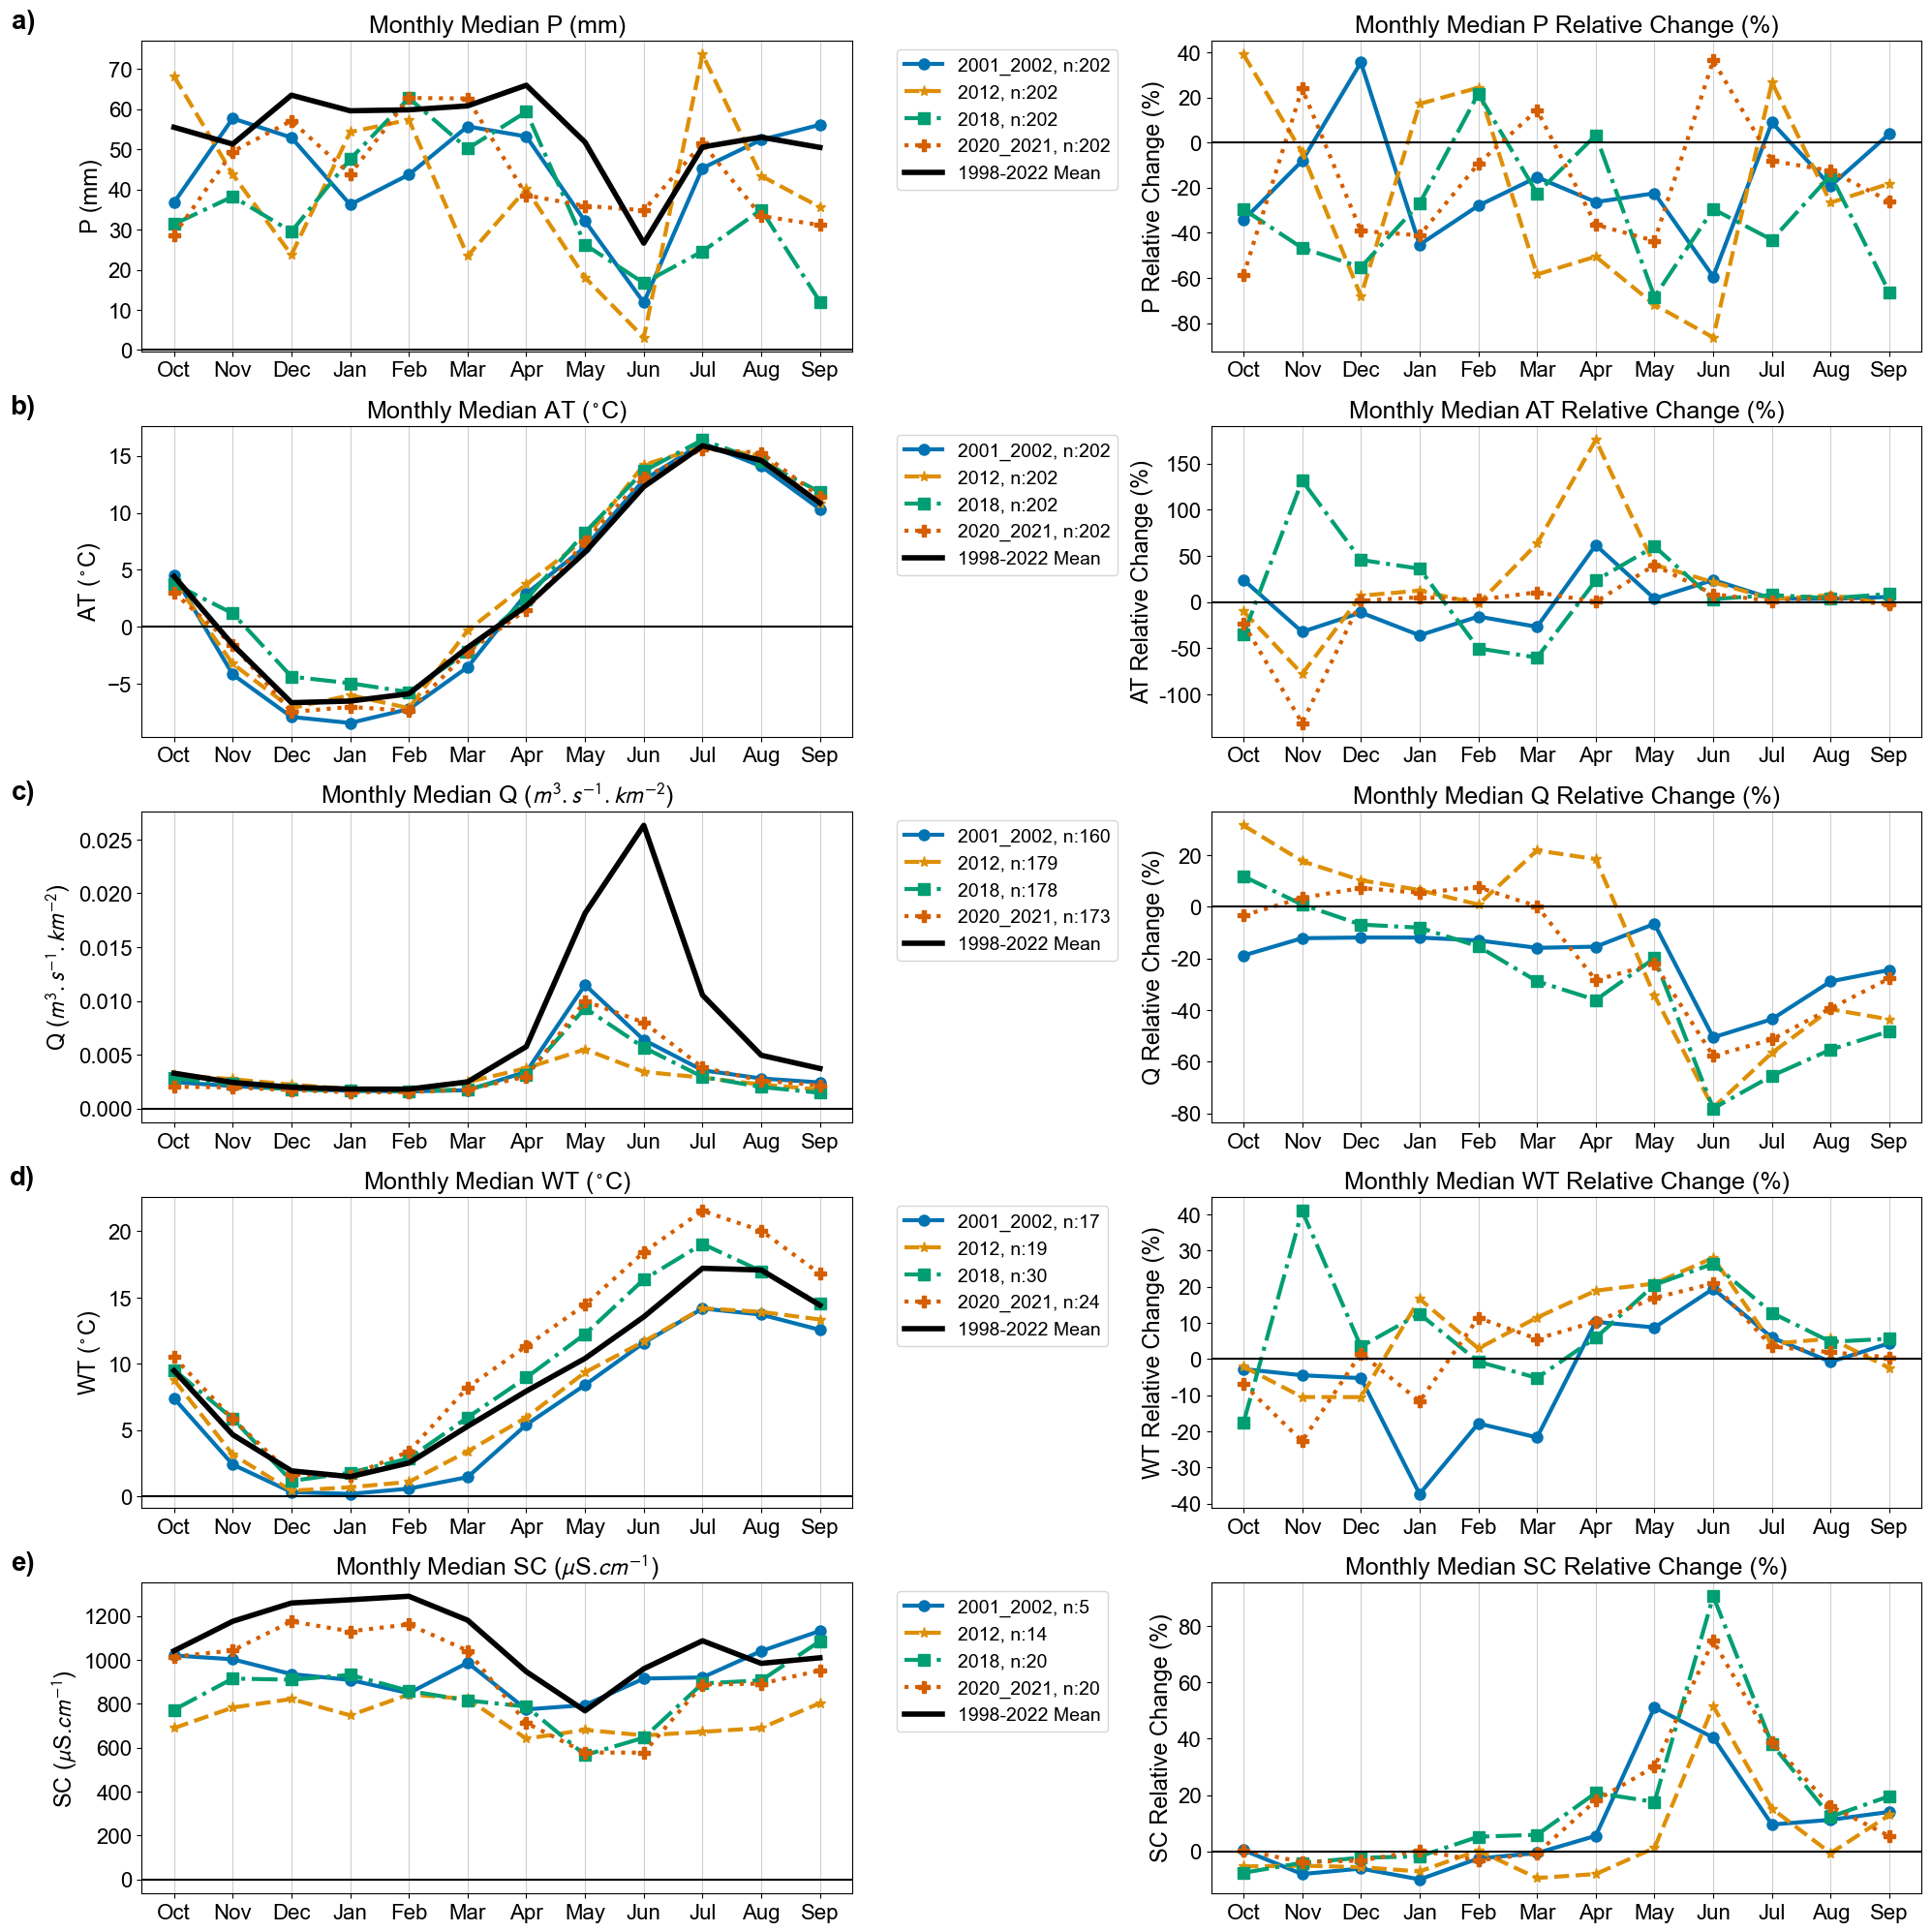

In [22]:
var_plot_names = {
    'RDC': r'Q ($m^{3}.s^{-1}.km^{-2}$)',
    'WT':  r'WT ($^\circ$C)',
    'SC':  r'SC ($\mu$S.$cm^{-1}$)'
}
var_rel_names = {'RDC': 'Q', 'WT': 'WT', 'SC': 'SC'}
met_plot_names = {
    'precip': ('P (mm)',         'P'),
    'temp':   (r'AT ($^\circ$C)', 'AT')
}

fig, axes = plotting.plot_combined_monthly_analysis(
    var_names          = var_names,
    dr_names           = dr_names,
    MET_vars           = MET_vars,
    mon_MED_drought    = mon_MED_drought,
    mon_MED_relchange  = mon_MED_relchange,
    basin_avg          = basin_avg,
    wmon_names         = wmon_names,
    dr_colors          = dr_colors,
    dr_markerstyles    = dr_markerstyles,
    dr_linestyles      = dr_linestyles,
    var_plot_names     = var_plot_names,
    var_rel_names      = var_rel_names,
    met_plot_names     = met_plot_names,
    longterm_avg_start = 1998,
    with_precip_temp   = True,
    fig_dir            = fig_dir,
    save               = True
)

#### Rel Change Data distribution - monthly

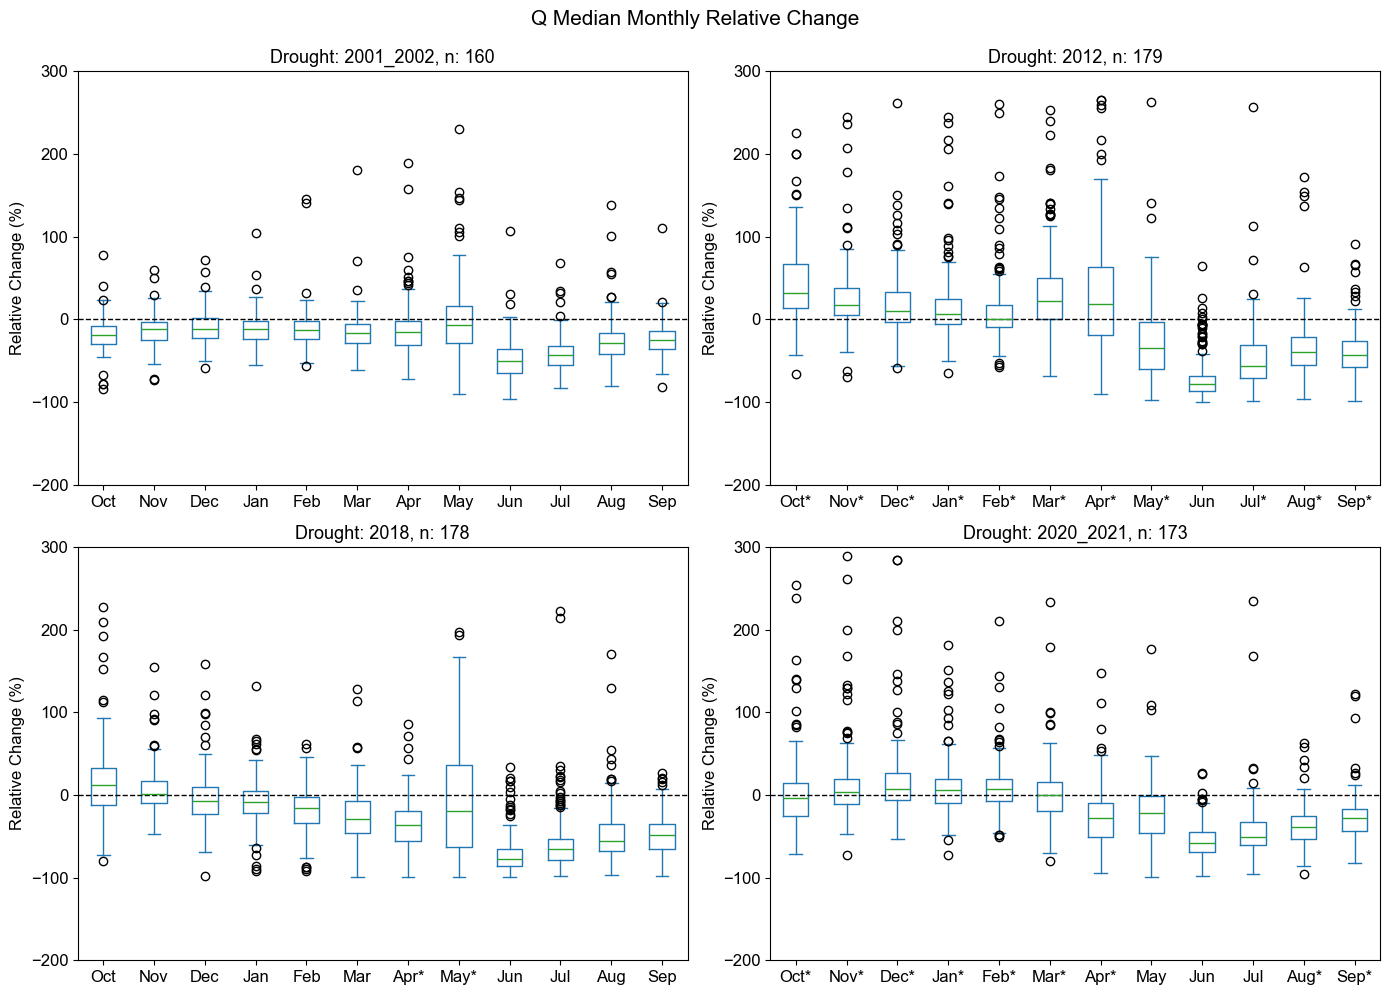

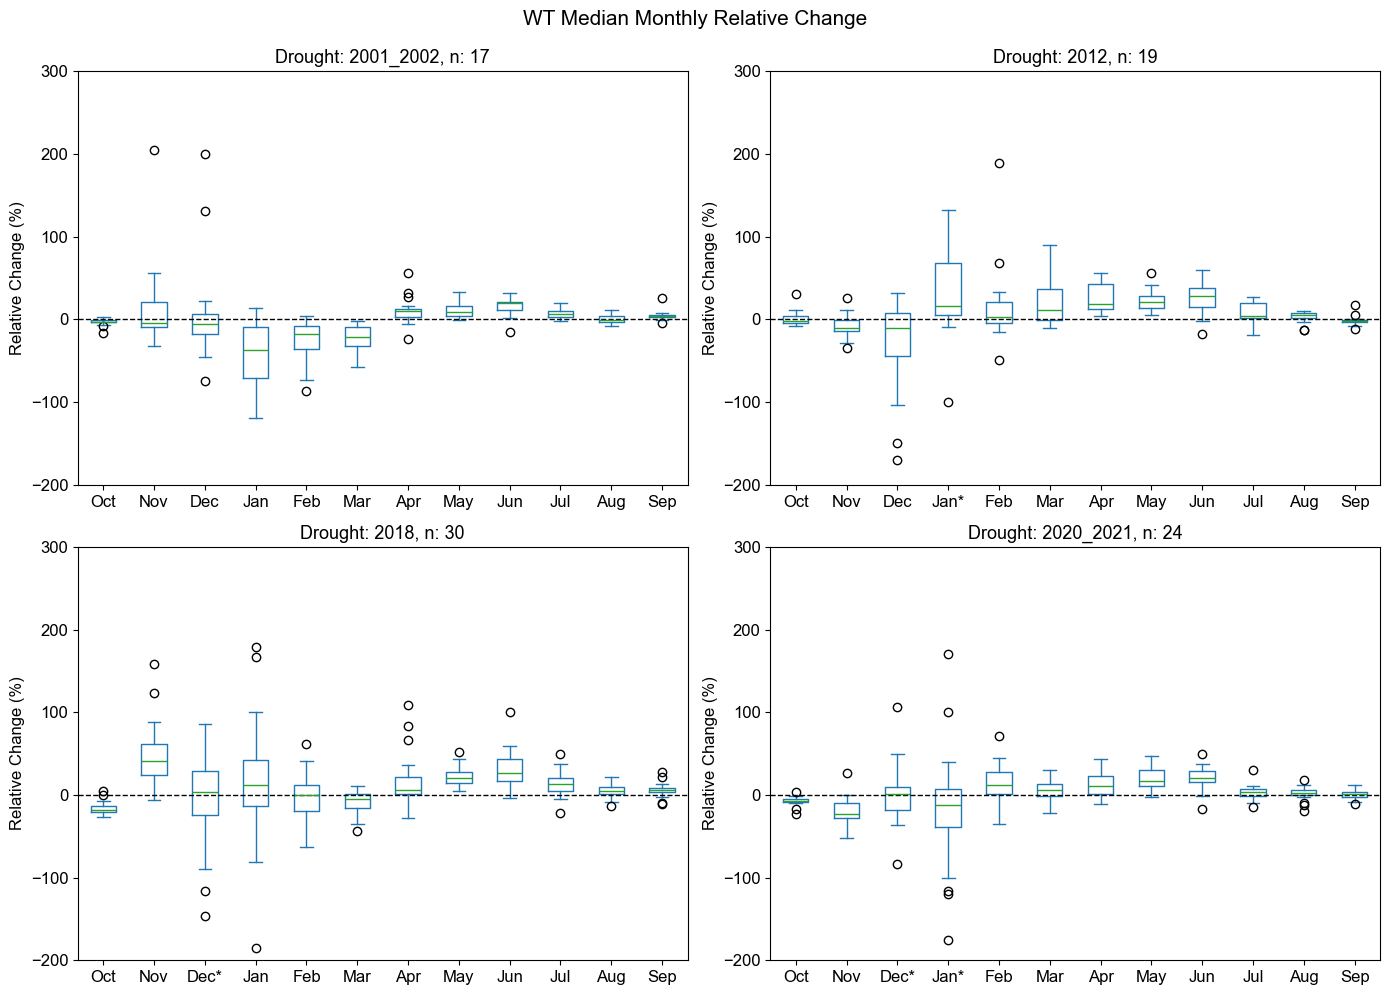

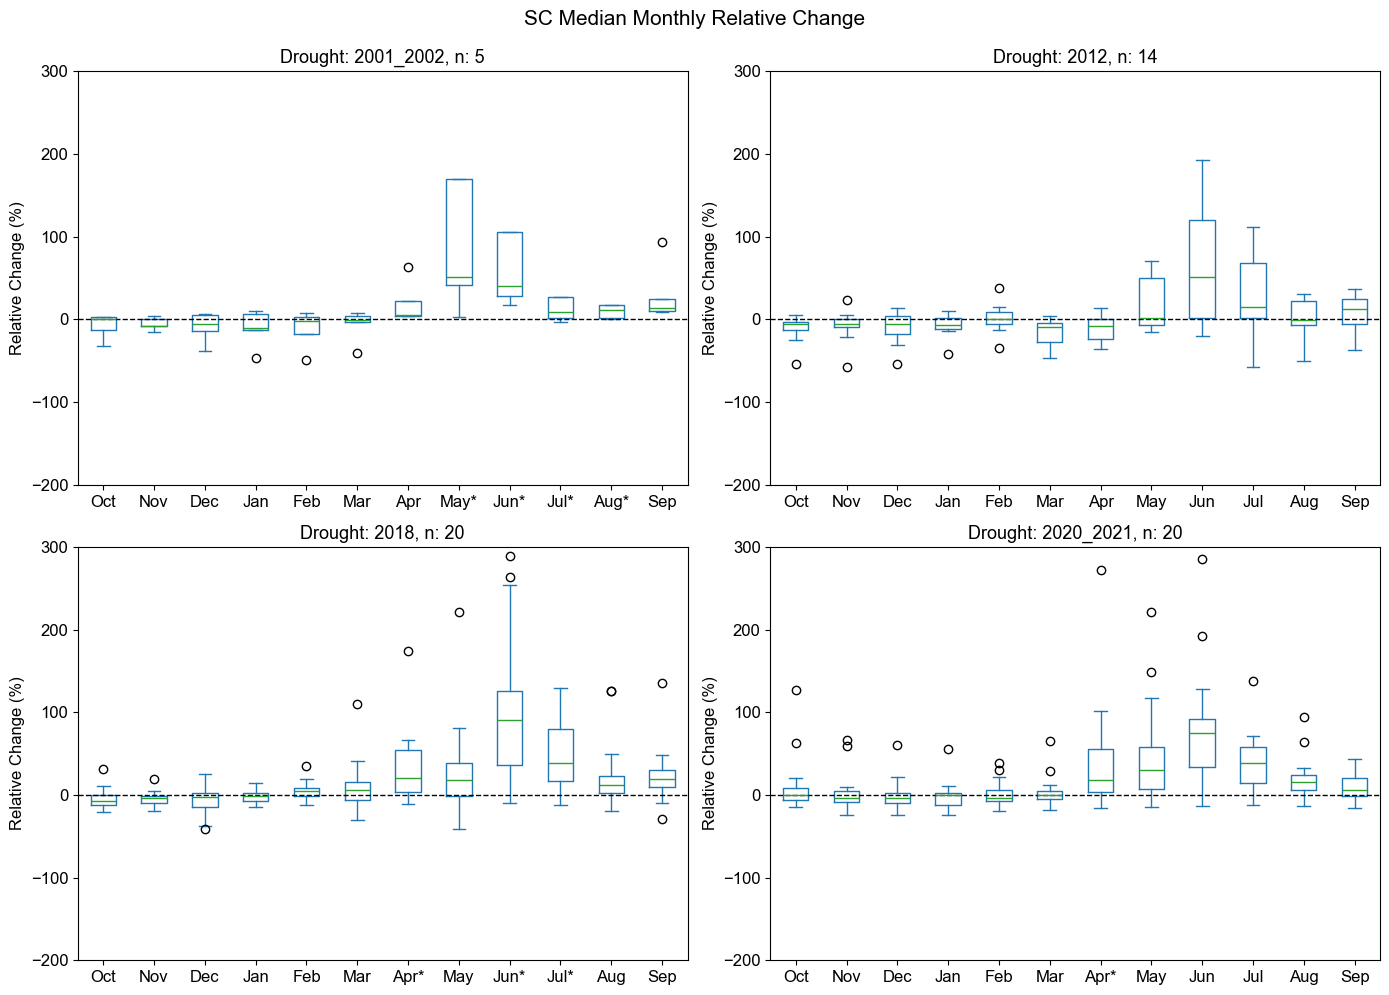

In [23]:
figs = plotting.plot_monthly_relchange_boxplots(
    var_names         = var_names,
    dr_names          = dr_names,
    mon_MED_relchange = mon_MED_relchange,
    wmon_names        = wmon_names,
    var_titles        = {'RDC': 'Q', 'WT': 'WT', 'SC': 'SC'},
    bottom            = -200,
    top               = 300,
    fig_dir           = fig_dir,
    save              = False
)

### 3.5 Save plot data

In [24]:
# SI Figure S.4, S.6, S.7, S.1
for var in var_names:
    for dr in dr_names:
        mon_MED[var][dr]['relchange'].to_csv(data_for_figures + f'{var}_mon_MED_relchange_{dr}.csv')
        mon_MED[var][dr]['drought'].to_csv(data_for_figures + f'{var}_mon_MED_drought_{dr}.csv')
        mon_MED[var][dr]['ref'].to_csv(data_for_figures + f'{var}_mon_MED_ref_{dr}.csv')
        
        ann_MED[var][dr]['relchange'].to_csv(data_for_figures + f'{var}_ann_MED_relchange_{dr}.csv')
        ann_MED[var][dr]['drought'].to_csv(data_for_figures + f'{var}_ann_MED_drought_{dr}.csv')
        ann_MED[var][dr]['ref'].to_csv(data_for_figures + f'{var}_ann_MED_ref_{dr}.csv')

for MET in MET_vars:
    for dr in dr_names:
        met_mon_MED[MET][dr]['relchange'].to_csv(data_for_figures + f'{MET}_mon_MED_relchange_{dr}.csv')
        met_mon_MED[MET][dr]['drought'].to_csv(data_for_figures + f'{MET}_mon_MED_drought_{dr}.csv')


In [25]:
# save longterm avg data data for all variables
basin_avg_df = pd.DataFrame(basin_avg)
basin_avg_df.to_csv(data_for_figures + 'mon_basin_avg_1998-2022.csv')


## 4. Mann-Kendall Trend Test - long term trend
SI Figure S.11

In [26]:
# Prep reservoir data
reservoirs_years, reservoirs_wyearsdaily = preprocessing.prep_reservoir_data(reservoirs_data)

# Run Mann-Kendall test
mk, years, withsites = calculations.run_mann_kendall_all(ready, met_wyear, runoff_efficiency_ann, reservoirs_years,var_names, MET_vars, allsites)

# Filter MK results by trend type
mk_trends = calculations.filter_mk_trends(mk)

------ reservoir data averaged to annual water year for MK test ------
------ computed MK test for RDC, WT, SC, precip, temp, runoff_efficiency, reservoirs ------
RDC , Sites per each type of trend result:
trend
no trend      184
decreasing     15
increasing      3
Name: count, dtype: int64
WT , Sites per each type of trend result:
trend
no trend      32
increasing     4
Name: count, dtype: int64
SC , Sites per each type of trend result:
trend
no trend      19
decreasing     2
increasing     2
Name: count, dtype: int64
precip , Sites per each type of trend result:
trend
no trend    202
Name: count, dtype: int64
temp , Sites per each type of trend result:
trend
no trend      141
increasing     61
Name: count, dtype: int64
runoff_efficiency , Sites per each type of trend result:
trend
no trend      182
decreasing     15
increasing      5
Name: count, dtype: int64
reservoirs , Sites per each type of trend result:
trend
no trend      29
decreasing    12
increasing     2
Name: count, dtype:

### 4.1 Plotting

Saved figures to /Users/emilynagamoto/PycharmProjects/drought-impacts-updates/UCRB-drought/OUTPUTS/Figures/


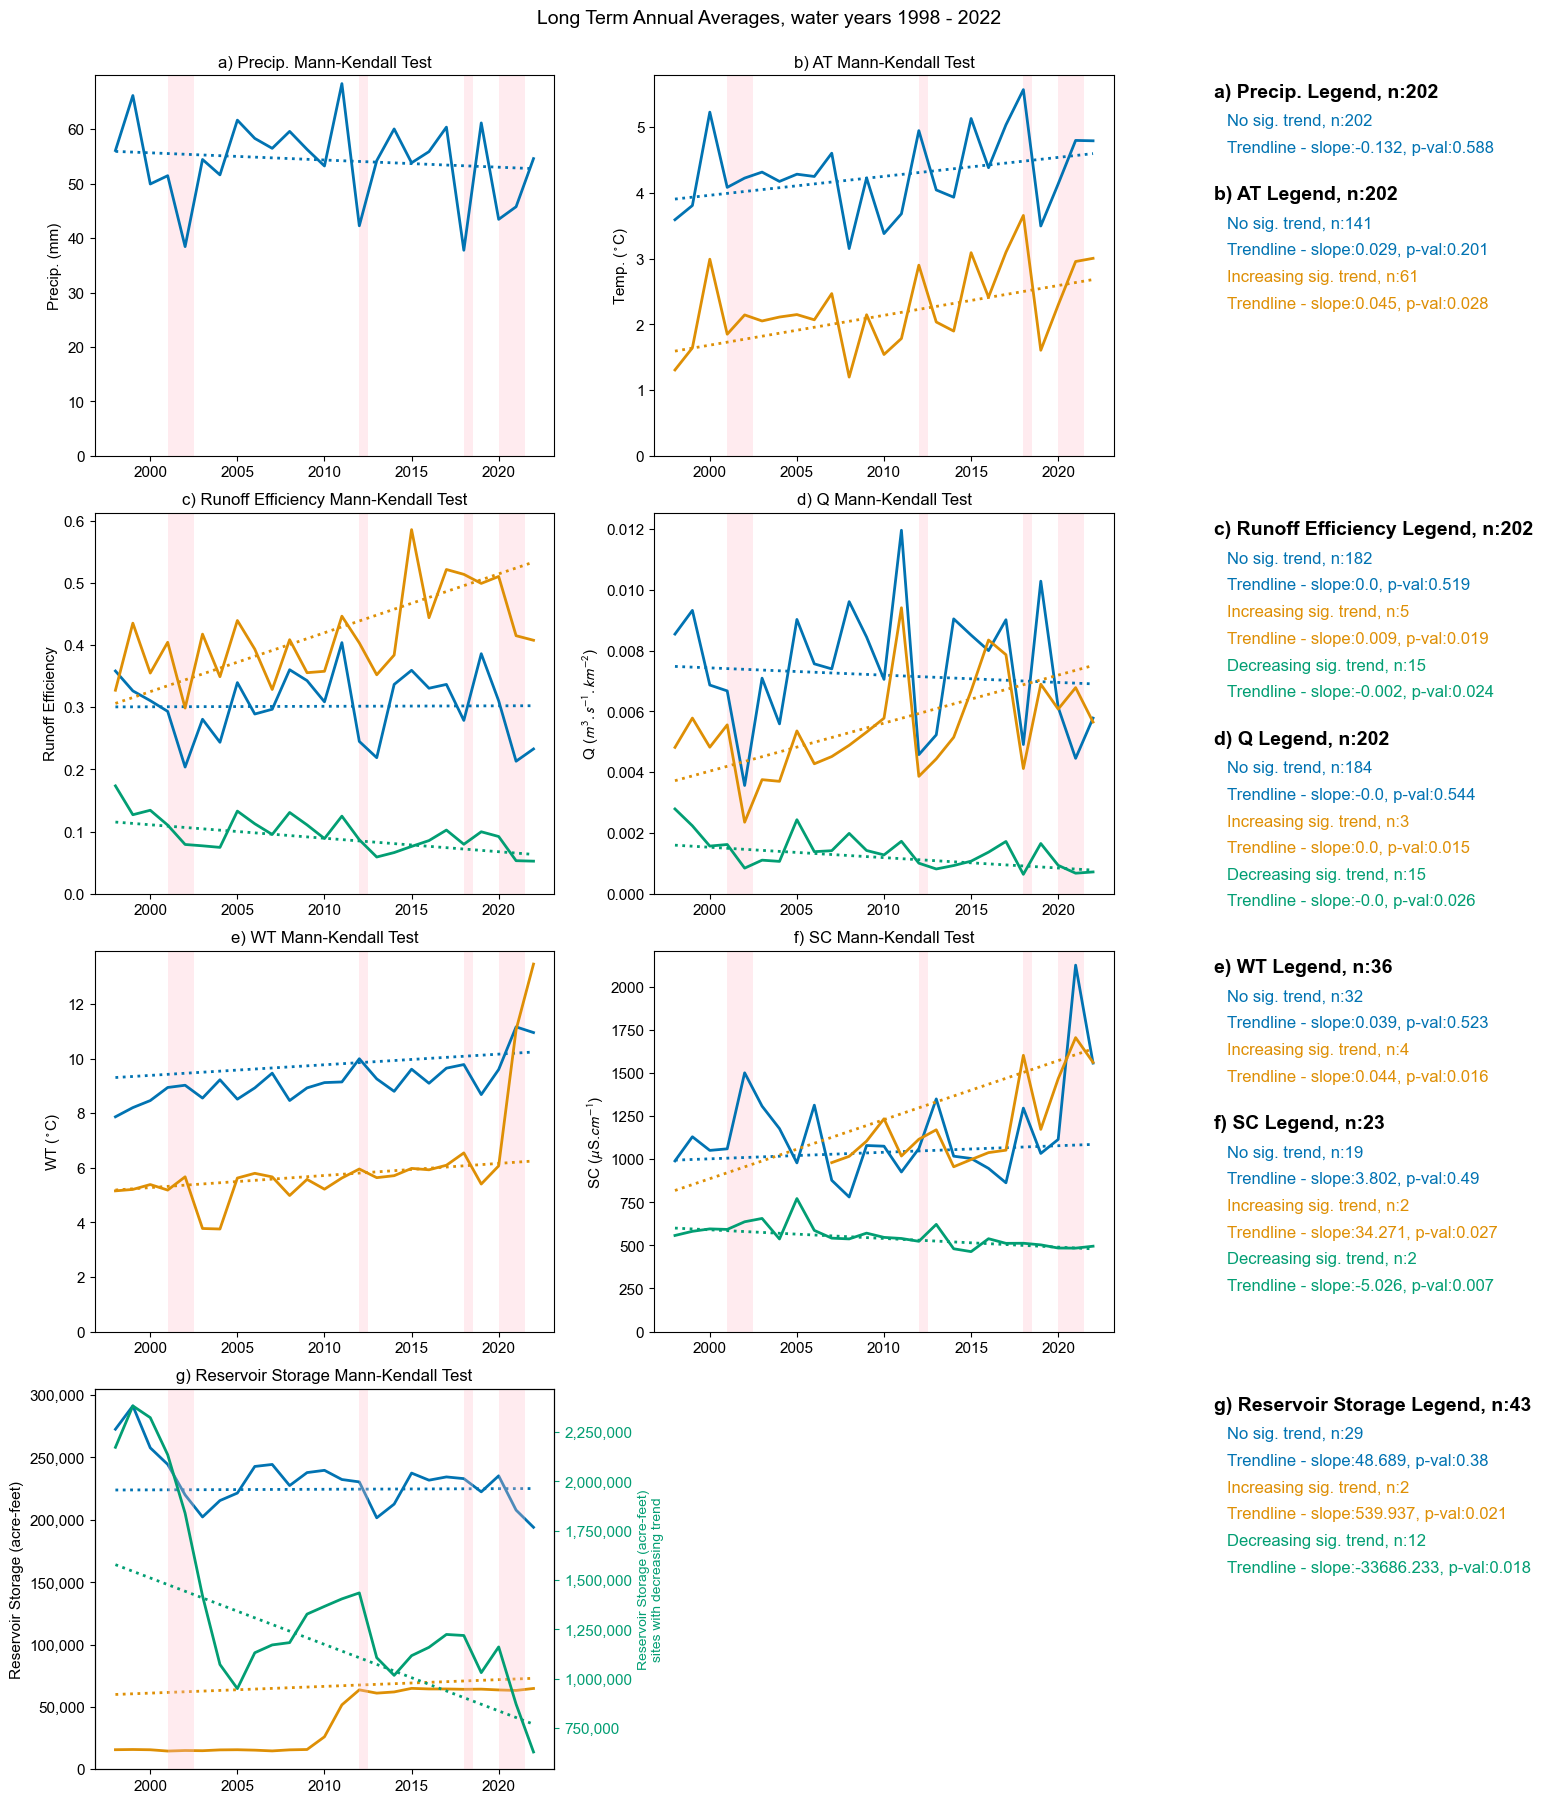

In [27]:
fig, all_handles = plotting.plot_combined_mk_trends(
    years         = years,
    mk_trends     = mk_trends,
    met_cmap      = met_cmap,
    var_layout    = None,   
    legend_layout = None,   
    fontsize      = 10,
    fig_dir       = fig_dir,
    save          = True
)

In [28]:
# save the data
for var in all_vars_qp:
    years[var].to_csv(data_for_figures + f'{var}_ann_values_1998-2022.csv')
    for trend in ['notrend', 'increasing', 'decreasing']:
        mk_trends[var][trend].to_csv(data_for_figures + f'{var}_MKtest_{trend}.csv')


## 5. Mapping the Relative Change

### 5.1 Maps of Rel Change

In [29]:
# MED_relchange with LAT, LON, CLASS 
list_metadata_filtered_dfs = [meta[var] for var in var_names]
list_mapping = [MED_all3[var]['relchange'] for var in var_names]

list_mapping_return = calculations.prep_mapping(list_mapping, list_metadata_filtered_dfs, gagesii)

Saved figures to /Users/emilynagamoto/PycharmProjects/drought-impacts-updates/UCRB-drought/OUTPUTS/Figures/


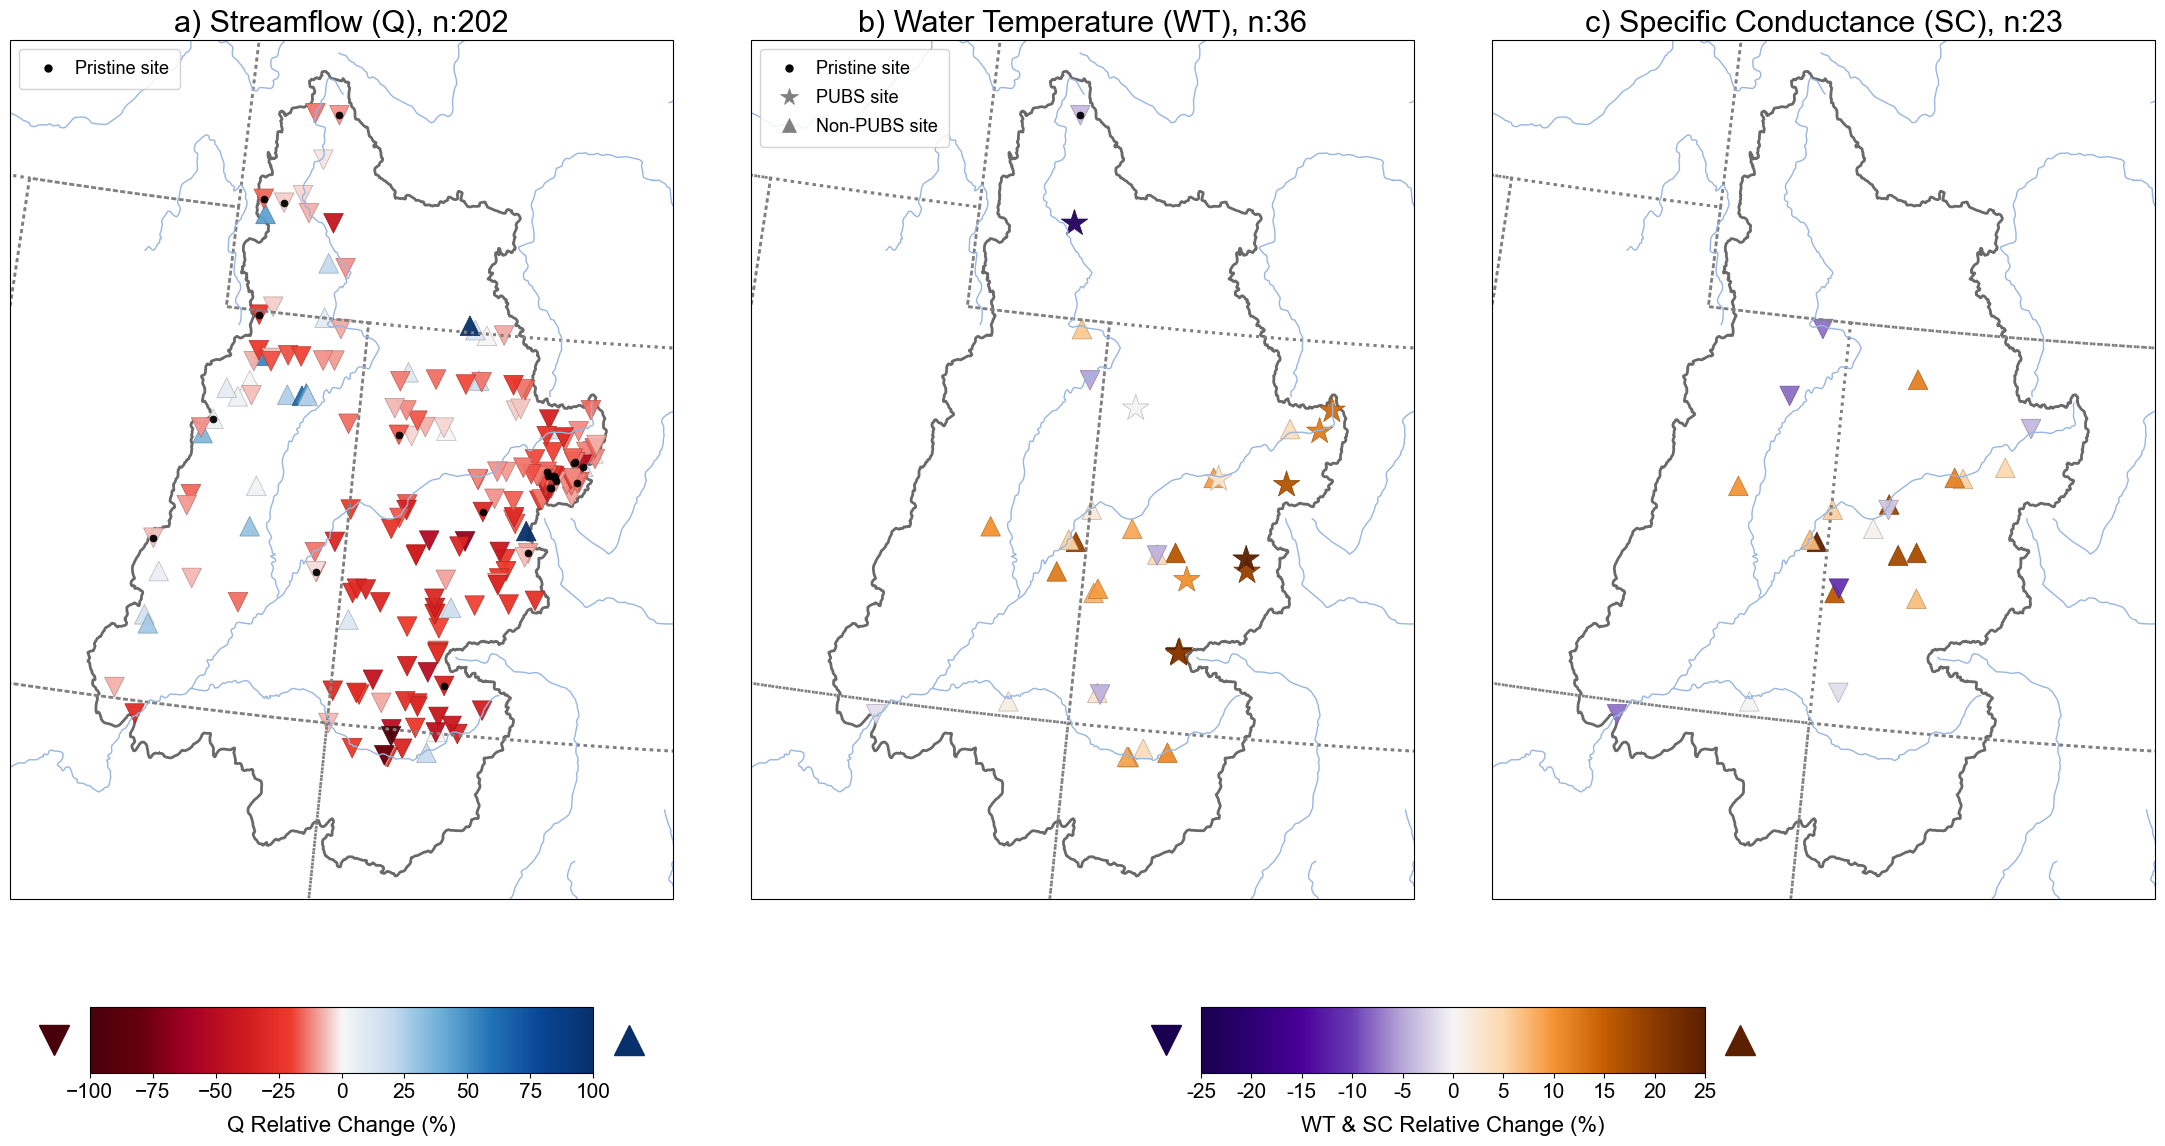

In [30]:
var_settings = {
    var_names[0]: {
        'colorscheme': dark_bwr,'vmin': -100, 'vmax': 100, 'title_label': 'a)', 'plot_name': 'Streamflow (Q)', 'cbar_ticks': None,'cbar_title': 'Q Relative Change (%)',
    },
    var_names[1]: {
        'colorscheme': dark_puor,'vmin': -25, 'vmax': 25,'title_label': 'b)', 'plot_name': 'Water Temperature (WT)','cbar_ticks': np.arange(-25, 30, 5),'cbar_title': 'WT & SC Relative Change (%)',
    },
    var_names[2]: {
        'colorscheme': dark_puor,'vmin': -25, 'vmax': 25, 'title_label': 'c)', 'plot_name': 'Specific Conductance (SC)','cbar_ticks': np.arange(-25, 30, 5),'cbar_title': 'WT & SC Relative Change (%)',
    },
}

fig, map_axes = plotting.plot_relchange_map(
    var_names= var_names,
    MED_relchange_map = list_mapping_return, 
    var_settings = var_settings,
    upper_colorado_river_boundary_dir = dirs['upper_colorado_river_boundary_dir'],
    PUBS_sites_all3=PUBS_sites_all3, 
    wt_var=var_names[1],
    extent=(-113, -105, 35.5, 43.5), 
    reservoirs_mktrend = None,
    fig_dir=fig_dir, 
    save=True)


### 5.2 Colocated plots Rel Change

In [31]:
all3_ann_MEDrelchange, all3_ann_MEDrelchange_allsites, all_sites = preprocessing.load_colocation_data(
    MED_relchange_map = list_mapping_return,
    ann_MED_relchange = ann_MED_relchange,
    var_names        = var_names,
    dr_names         = dr_names,
    all3vars         = all3vars)


------ Co-location data loaded ------


Saved figures to /Users/emilynagamoto/PycharmProjects/drought-impacts-updates/UCRB-drought/OUTPUTS/Figures/


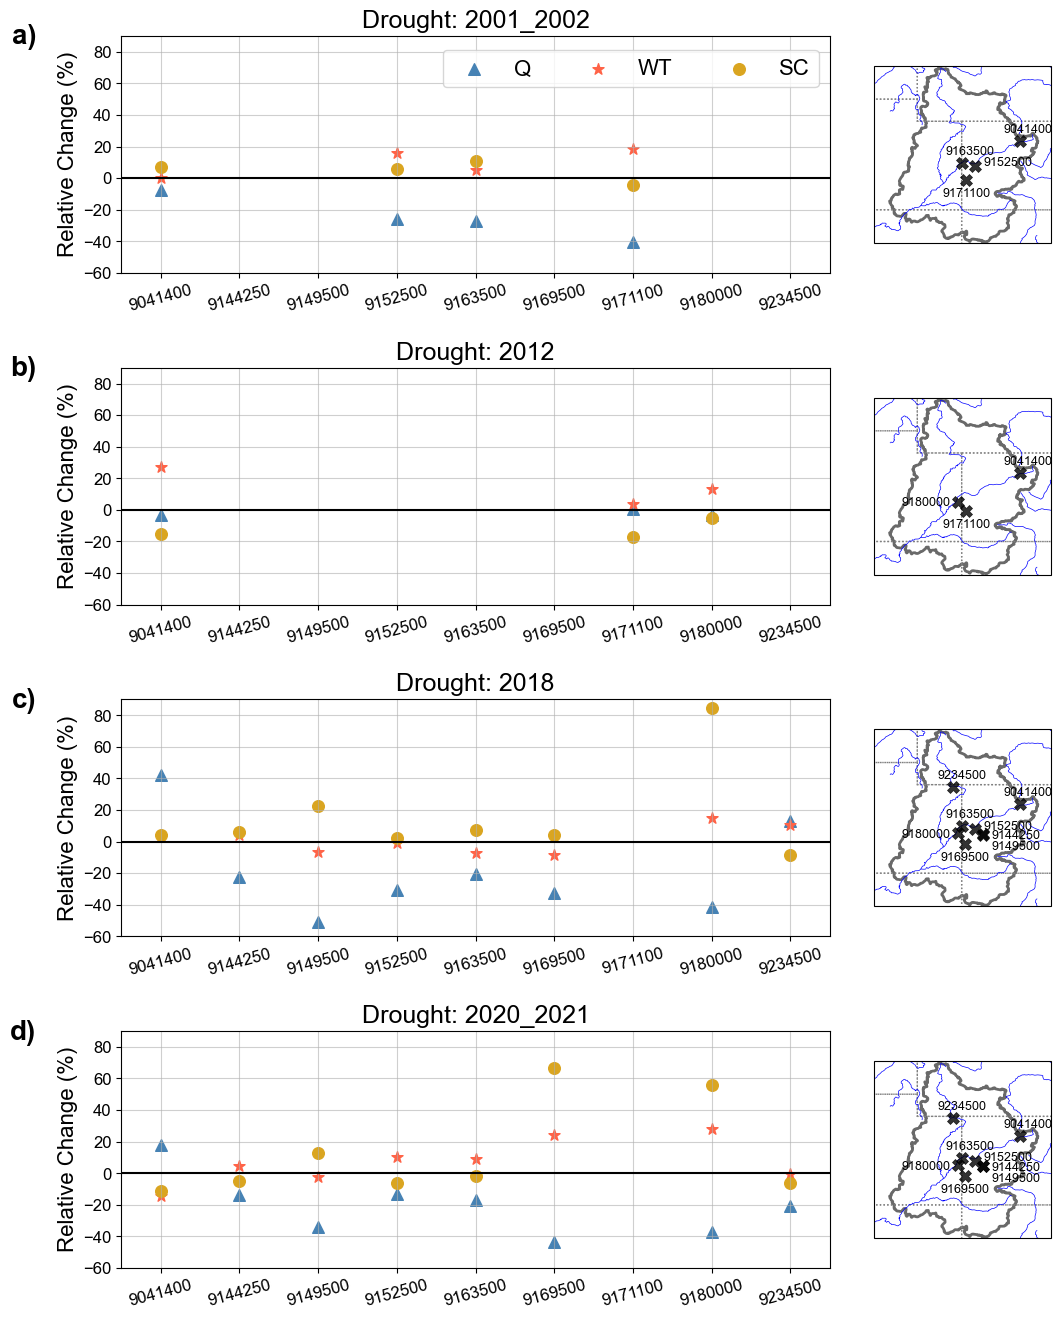

In [32]:
fig = plotting.plot_colocation_relchange(
    var_names                        = var_names,
    dr_names                         = dr_names,
    all3_ann_MEDrelchange_allsites   = all3_ann_MEDrelchange_allsites,
    all_sites                        = all_sites,
    all3vars                         = all3vars,
    MED_relchange_map                = list_mapping_return,
    upper_colorado_river_boundary_dir = dirs['upper_colorado_river_boundary_dir'],
    var_markers                      = None, # same as graphical abstract
    var_labels                       = None,
    var_colors                       = None, # same as graphical abstract
    ylim                             = (-60, 90),
    extent                           = (-113, -105, 35.5, 43.5),
    fontsize                         = 16,
    fig_dir                          = fig_dir,
    save                             = True
)

Saved figures to /Users/emilynagamoto/PycharmProjects/drought-impacts-updates/UCRB-drought/OUTPUTS/Figures/


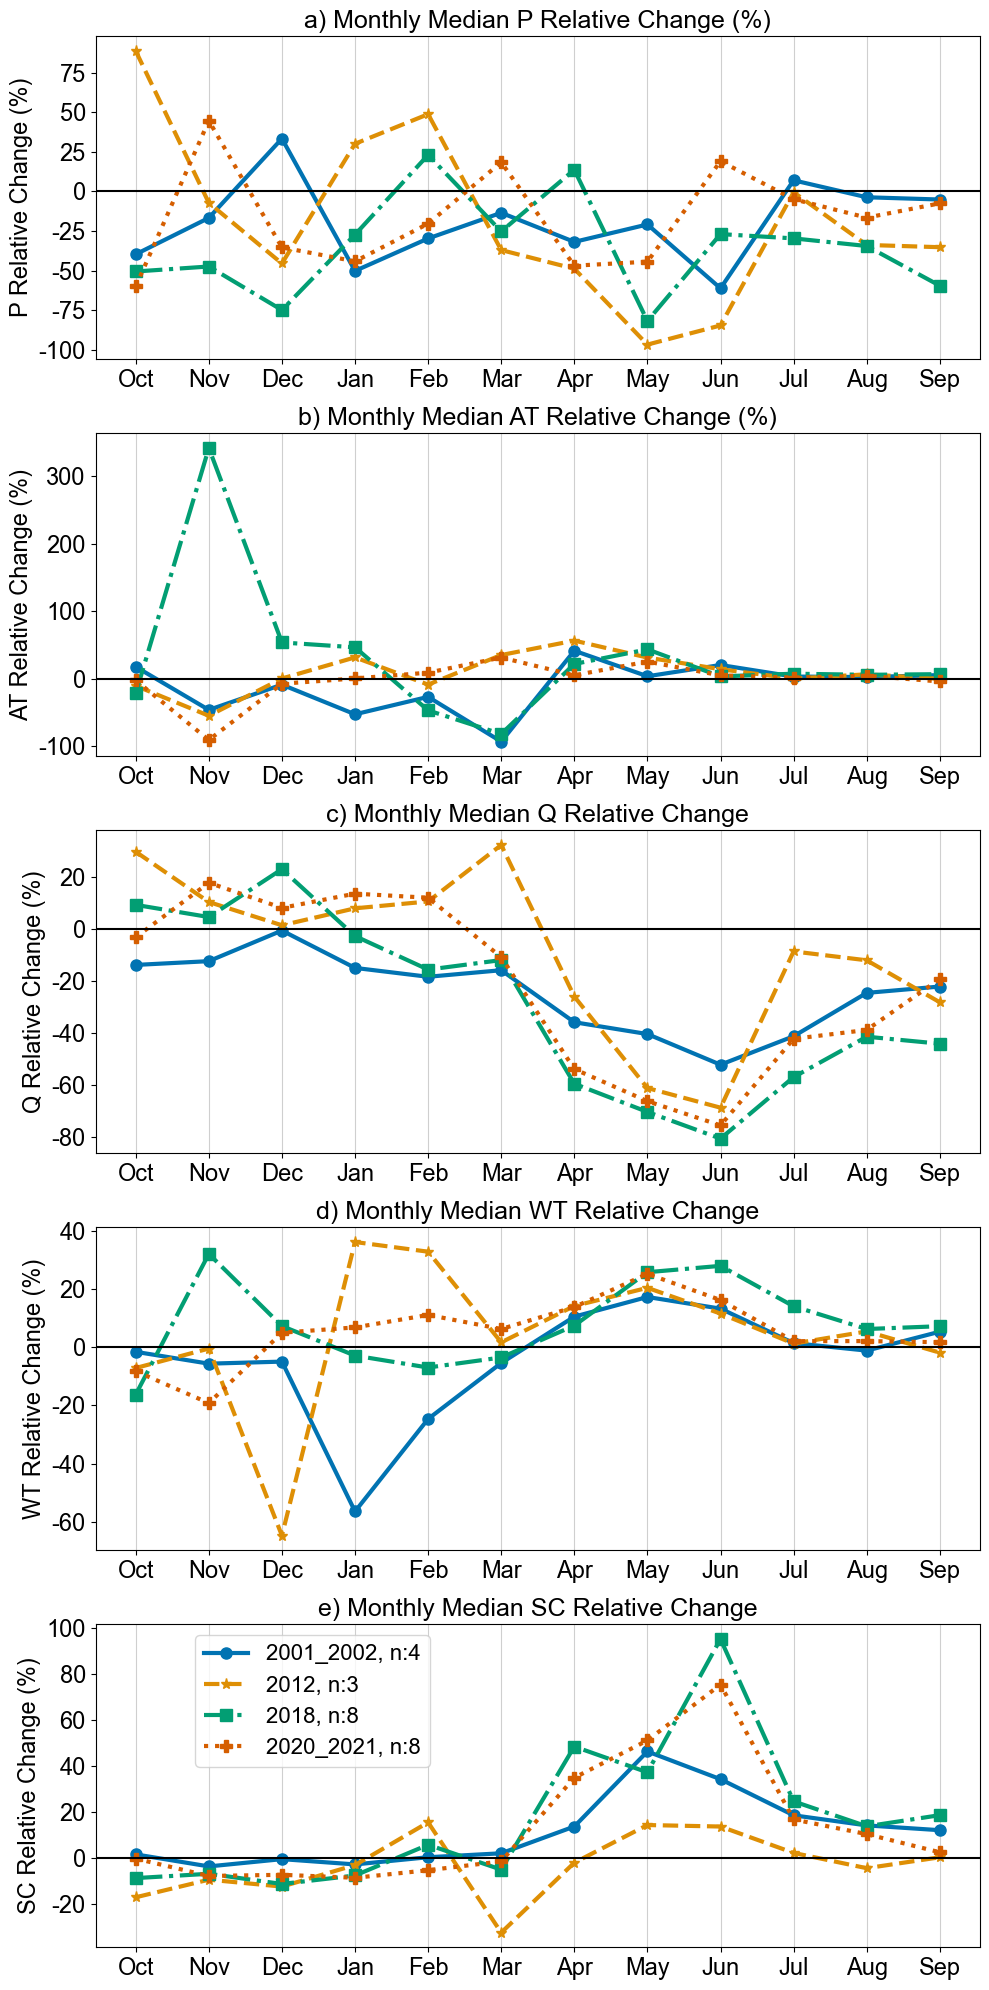

In [33]:
# seasonal
fig, axs = plotting.plot_colocation_seasonal_relchange(
    var_names                        = var_names,
    dr_names                         = dr_names,
    MET_vars                         = MET_vars,
    all3_ann_MEDrelchange   = all3_ann_MEDrelchange,
    all_sites                        = all_sites,
    mon_MED_relchange                = mon_MED_relchange, 
    wmon_names                       = wmon_names,
    dr_colors                        = dr_colors,
    dr_markerstyles                  = dr_markerstyles,
    dr_linestyles                    = dr_linestyles, 
    ylim                             = (-60, 90),
    extent                           = (-113, -105, 35.5, 43.5),
    fontsize                         = 16,
    with_precip_temp                 = True, 
    same_yaxis                       = False, 
    fig_dir                          = fig_dir, 
    save                             = True 
)

### 5.3 Save plotting data

In [34]:
## ann rel change mapping!
for var in var_names:
    list_mapping_return[var].to_csv(data_for_figures + f'{var}_MED_relchange_map.csv')

# save the list of colocated sites!
pd.DataFrame({dr: pd.Series(all3vars[dr]) for dr in dr_names}).to_csv(data_for_figures + 'all3vars.csv', index=False)

## 6. 95th and 5th Percentiles - RDC, WT, SC

In [35]:
pct = calculations.calculate_percentile_rel_change(var_names, dr_names, refyrs_all3, dryrs_all3)

------ calculated relative change for peak and low RDC, WT, SC ------


### 6.1 Plotting

In [36]:
pct_map = calculations.calculate_percentile_map_data(
    var_names                  = var_names,
    dr_names                   = dr_names,
    pct                        = pct,
    list_metadata_filtered_dfs = list_metadata_filtered_dfs,
    gagesii                    = gagesii
)

------ Percentile map data prepared ------


Saved figures to /Users/emilynagamoto/PycharmProjects/drought-impacts-updates/UCRB-drought/OUTPUTS/Figures/


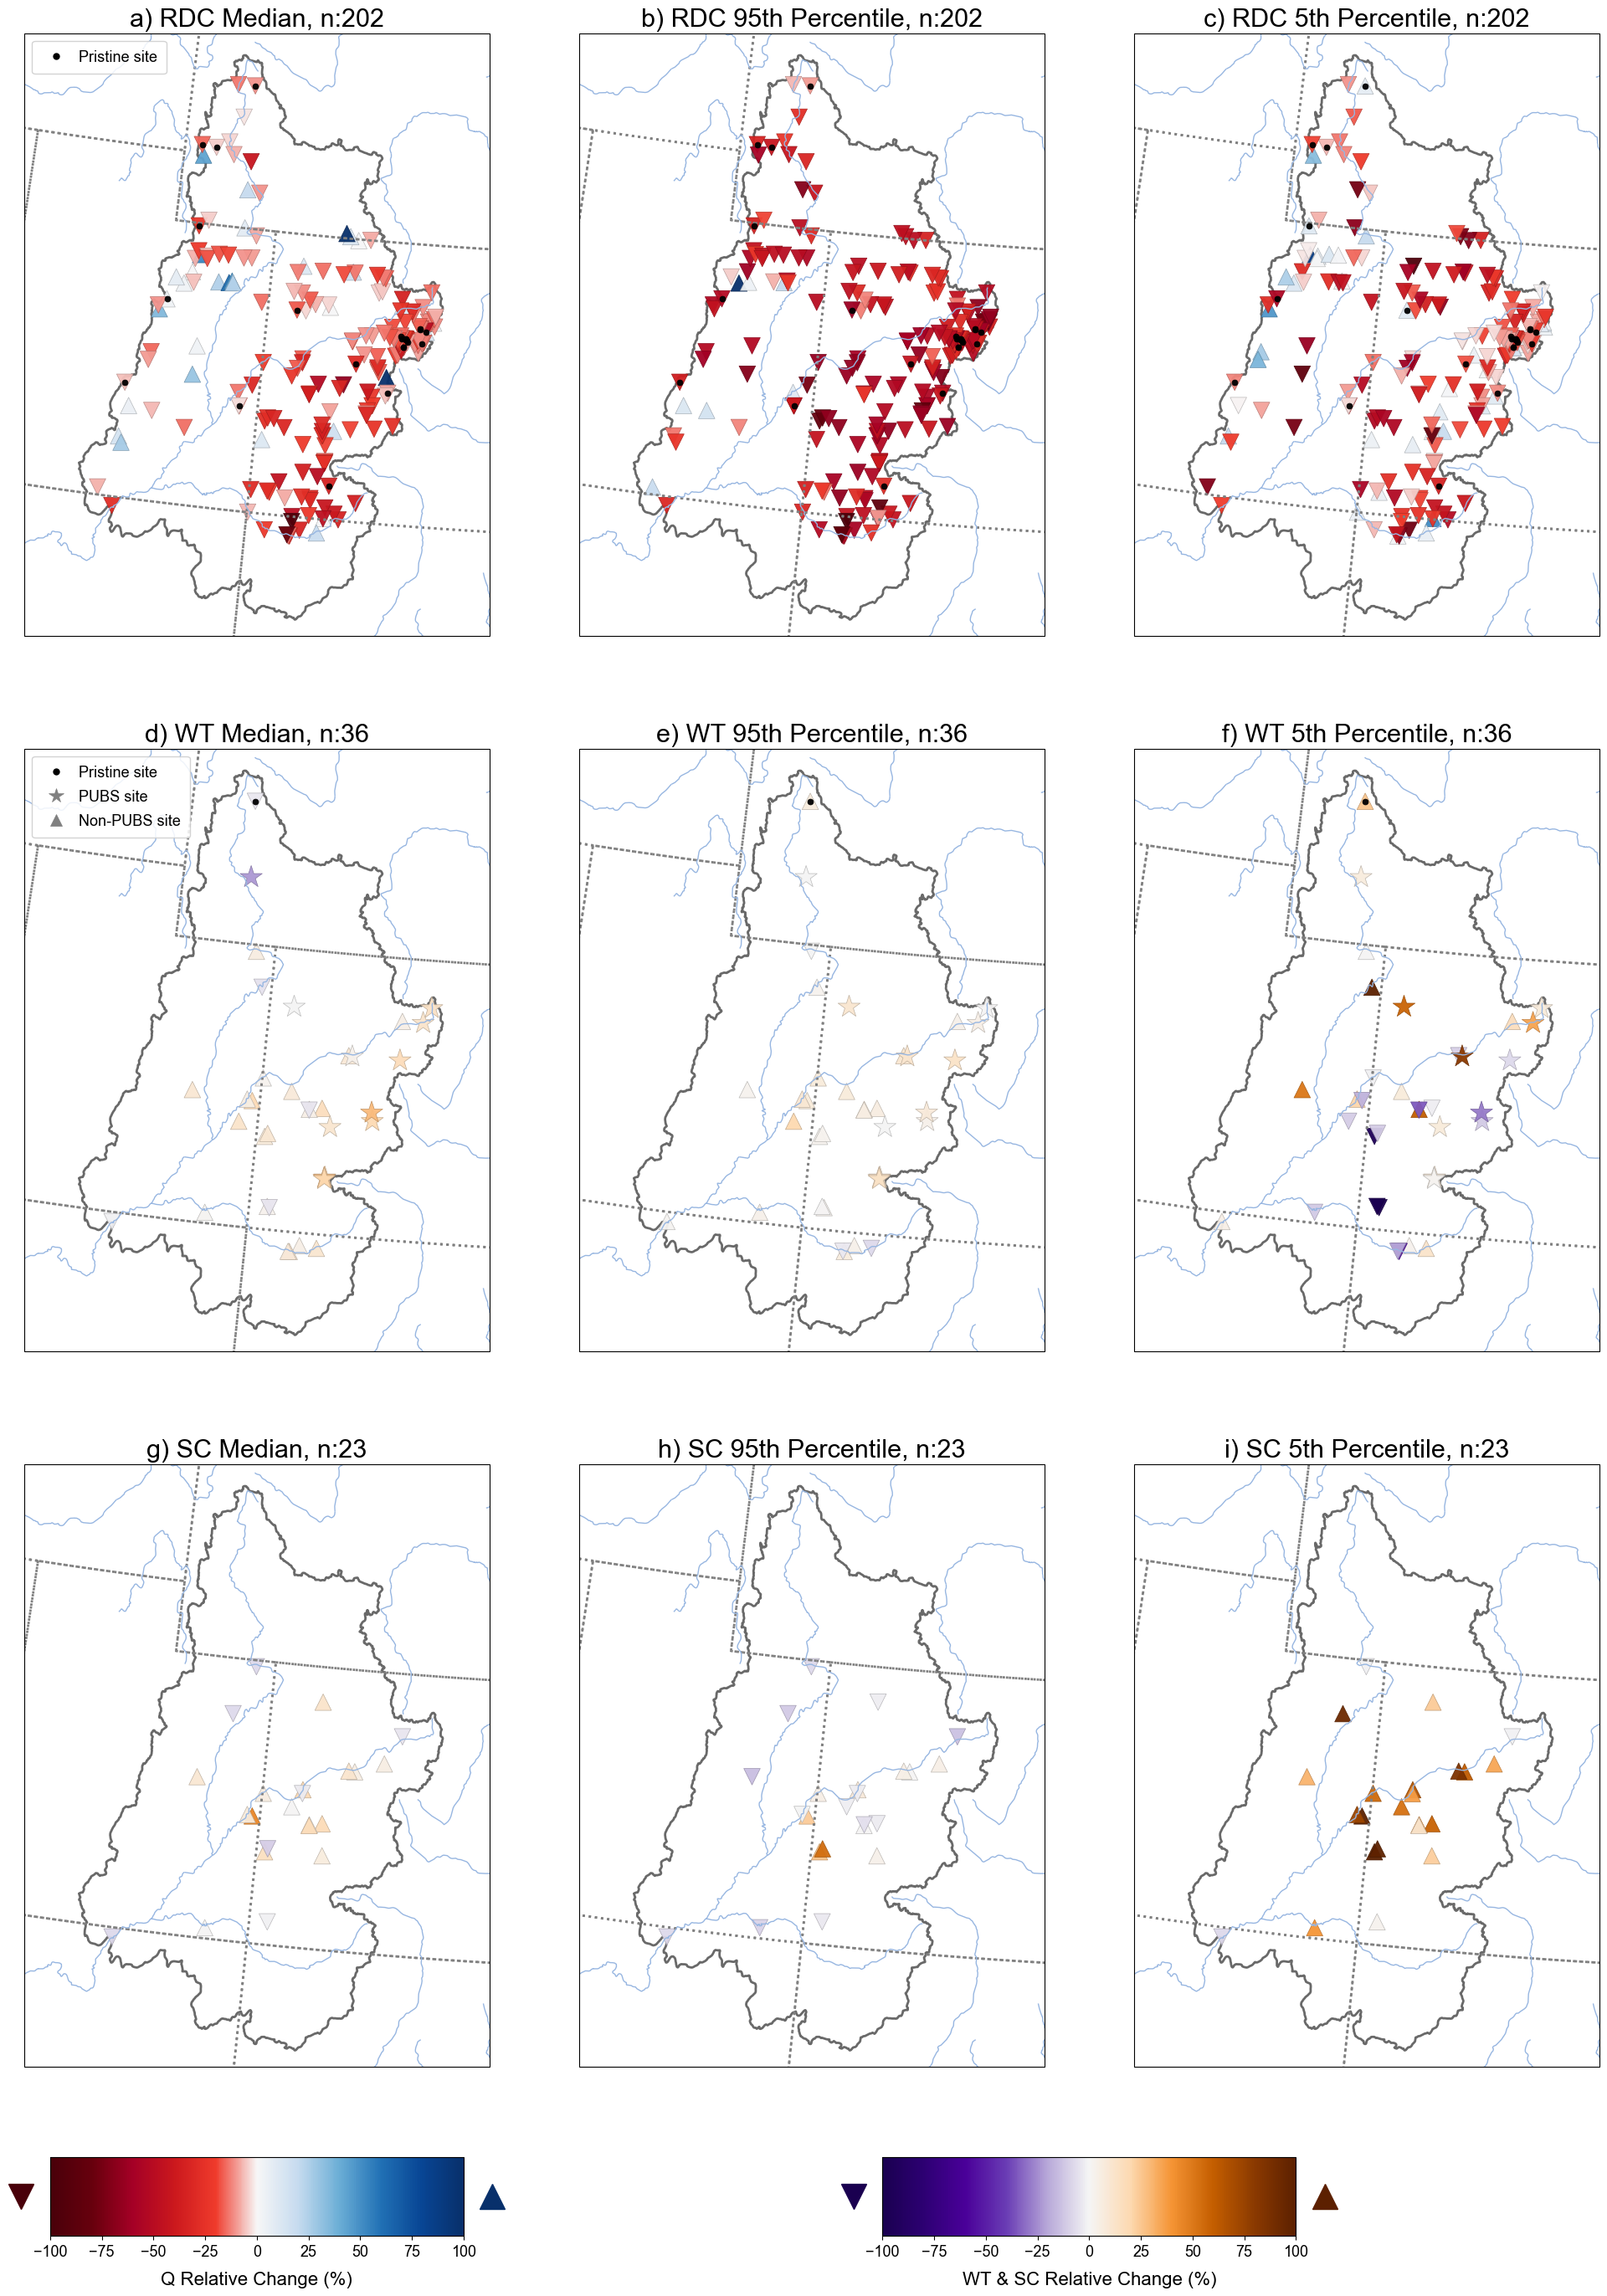

In [37]:
colorschemes = {var: (dark_bwr if i == 0 else dark_puor) for i, var in enumerate(var_names)}

fig, axes = plotting.plot_relchange_percentile_maps(var_names, list_mapping_return, pct_map,
                                   dirs['upper_colorado_river_boundary_dir'],colorschemes=colorschemes,
                                   title_labels=None, vmin_vmax=None,
                                   PUBS_sites_all3=PUBS_sites_all3, wt_var=None,
                                   extent=(-113, -105, 35.5, 43.5),
                                   fig_dir=fig_dir, save=True)

In [38]:
# save data for map
for var in var_names:
    for per in ['95', '5']:
        pct_map[var][per].to_csv(data_for_figures + f'{var}_relchange_map_percen_{per}.csv')

## 7. P vs Q - rainfall runoff analysis from Saft et al.
SI Figure S.12

From Saft et al (2015): <br>
- daily data were summed to months, seasons, and calendar years **[CHANGED to water years]**
- Months with >3 days missing Q data + years with >15 days (4.1%) missing Q were excluded, Smaller gaps = infilled based on daily avg of current month **[CHANGED to what OUR data criteria is]**
- annual rainfall data assumed to follow an approx. normal distribution
- annual runoff data transformed with a Box-Cox transformation
- Q=annual runoff, P=annual rainfall, I=drought indicator (set to 1 for years of a single dry period of interest and 0 for all other years including other dry periods), a0=intercept of the general regression line, a1 and a2 = regression coefficients, and ε = residual from the regression.
- t-test on a1 (the coefficient for the drought indicator) is applied to test the null hypothesis that a1=0 against the alternative that a1≠0.
- Q = a0 + a1xl + a2xP + ε
- tests were only run for cases with at least five runoff data points. Where multiple dry periods existed for a single catchment, they were examined separately. **[CHANGED OUR drought years as one analysis]**
- Calculate lag-1 autocorrelation $\rho$ of the residuals following Wallis and O'Connell [1972, equation (3)]
- all variables transformed following Haan [2002, p. 258]: variable at each time step is reduced by the value of autocorrelation multiplied by the variable at the previous time step
- Re-fit the regression on transformed variables.

In [39]:
# Prep regression data
runoff_years, P_years = preprocessing.prep_regression_data(met_wyear, runoff_ann, allsites)

# Run regression analysis
results, sig_pos, sig_neg, notsig, runoff_boxcox, I_all = calculations.run_regression_analysis(
    runoff_years, P_years, list_dr_years
)

# Select example sites for plotting
sites_plot = [notsig[0], sig_pos[0], sig_neg[0]]

------ prepped P and runoff for regression ------
Significant a1:          7
Positive significant a1: 5
Negative significant a1: 2
Not significant a1:      195


### 7.1 Plotting

Saved figures to /Users/emilynagamoto/PycharmProjects/drought-impacts-updates/UCRB-drought/OUTPUTS/Figures/


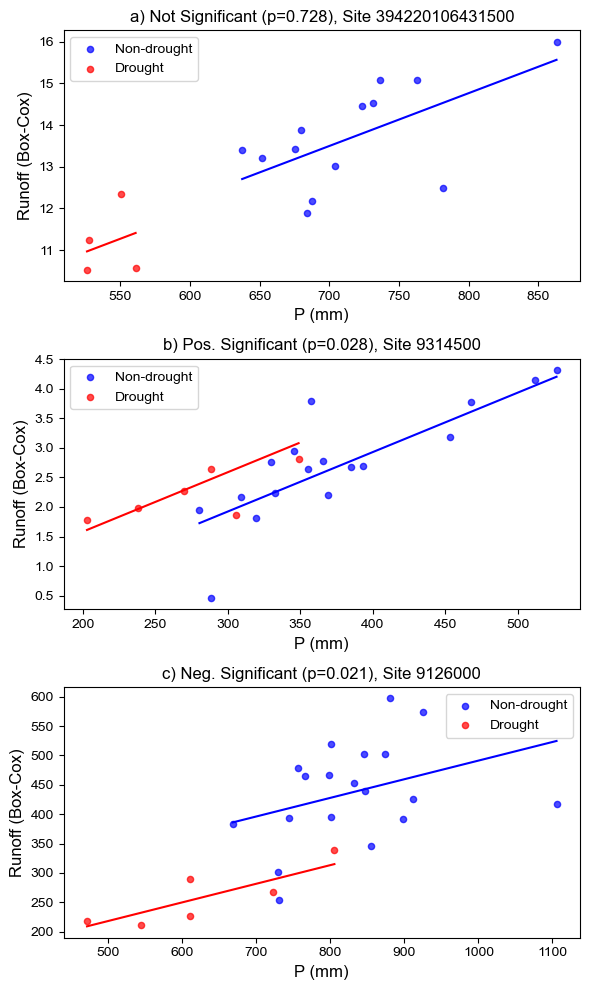

In [40]:
fig, axes = plotting.plot_pq_scatter_ex_sites(
    sites_plot    = sites_plot,
    runoff_boxcox = runoff_boxcox,
    P_years       = P_years,
    I_all         = I_all,
    results       = results,
    panel_labels  = None,    # auto-generates a), b), c)
    fig_dir       = fig_dir,
    save          = True
)

In [41]:
## save data from plot
# Save regression inputs and results 
results.to_csv(data_for_figures + 'pq_regression_results.csv')
runoff_boxcox.to_csv(data_for_figures + 'runoff_boxcox.csv')
P_years.to_csv(data_for_figures + 'P_years.csv')

# I_all is a dict keyed by site - convert to DataFrame for saving
pd.DataFrame(I_all).to_csv(data_for_figures + 'I_all.csv')

# Save sites_plot
pd.Series(sites_plot).to_csv(data_for_figures + 'sites_plot.csv', index=False)

## 8. Recovery Analysis 

### 8.1 Years to Recovery
SI Figure S.9 and Table S.12

In [42]:
## RDC, WT, SC
# Separate sites by relative change sign and build annual medians
MED_relchange_map, sites_by_rc, combined_dr, annual_medians, ann_med_rc = calculations.build_annual_medians_by_rc(var_names, dr_names, MED_all3, sites_all3)

# Accumulate first year back and years since recovery
firstyrback, numyears = calculations.build_recovery_year_dicts(var_names, dr_names, dr_years_list, ref_all3, ann_med_rc)

# Calculate recovery with data availability filtering
recovery, dr_timing = calculations.calculate_recovery(var_names, dr_names, dr_years_list, ref_all3, ann_med_rc,sites_all3, avail, numyears, firstyrback)

# Build final recovery summary DataFrames
alldr_recyrs_df = calculations.build_recovery_summary(var_names, dr_names, recovery)

------ separated sites by relative change sign and built annual medians ------
------ calculated number of years to pre-event baseline ------
RDC 2001_2002 pos
  Did not reach recovery: 1; Missing data to 2022: 0
  Mean yrs:   1.00; Median yrs: 1.00; Max yrs:    1.00; Min yrs:    1.00
RDC 2001_2002 neg
  Did not reach recovery: 26; Missing data to 2022: 6
  Mean yrs:   5.02; Median yrs: 4.00; Max yrs:    15.00; Min yrs:    1.00
RDC 2012 pos
  Did not reach recovery: 0; Missing data to 2022: 0
  Mean yrs:   1.07; Median yrs: 1.00; Max yrs:    3.00; Min yrs:    1.00
RDC 2012 neg
  Did not reach recovery: 7; Missing data to 2022: 1
  Mean yrs:   2.34; Median yrs: 2.00; Max yrs:    7.00; Min yrs:    1.00
RDC 2018 pos
  Did not reach recovery: 1; Missing data to 2022: 0
  Mean yrs:   1.48; Median yrs: 1.00; Max yrs:    3.00; Min yrs:    1.00
RDC 2018 neg
  Did not reach recovery: 123; Missing data to 2022: 5
  Mean yrs:   2.14; Median yrs: 2.00; Max yrs:    4.00; Min yrs:    1.00
RDC 2020_2

In [95]:
## RE only
MED_relchange_map_RE, sites_by_rc_RE, combined_dr_RE, annual_medians_RE, ann_med_rc_RE = calculations.build_annual_medians_by_rc(['RE'], dr_names, MED_all3_RE, sites_all3_RE)

# Accumulate first year back and years since recovery
firstyrback_RE, numyears_RE = calculations.build_recovery_year_dicts(['RE'], dr_names, dr_years_list, ref_all3, ann_med_rc_RE)

# Calculate recovery with data availability filtering
recovery_RE, dr_timing_RE = calculations.calculate_recovery(['RE'], dr_names, dr_years_list, ref_all3, ann_med_rc_RE,sites_all3_RE, avail_RE, numyears_RE, firstyrback_RE)

# Build final recovery summary DataFrames
alldr_recyrs_df_RE = calculations.build_recovery_summary(['RE'], dr_names, recovery_RE)


------ separated sites by relative change sign and built annual medians ------
------ calculated number of years to pre-event baseline ------
RE 2001_2002 pos
  Did not reach recovery: 1; Missing data to 2022: 0
  Mean yrs:   1.14; Median yrs: 1.00; Max yrs:    2.00; Min yrs:    1.00
RE 2001_2002 neg
  Did not reach recovery: 3; Missing data to 2022: 1
  Mean yrs:   4.05; Median yrs: 3.00; Max yrs:    13.00; Min yrs:    1.00
RE 2012 pos
  Did not reach recovery: 0; Missing data to 2022: 0
  Mean yrs:   1.32; Median yrs: 1.00; Max yrs:    5.00; Min yrs:    1.00
RE 2012 neg
  Did not reach recovery: 23; Missing data to 2022: 3
  Mean yrs:   3.37; Median yrs: 3.00; Max yrs:    7.00; Min yrs:    2.00
RE 2018 pos
  Did not reach recovery: 2; Missing data to 2022: 0
  Mean yrs:   1.75; Median yrs: 1.00; Max yrs:    4.00; Min yrs:    1.00
RE 2018 neg
  Did not reach recovery: 32; Missing data to 2022: 0
  Mean yrs:   1.02; Median yrs: 1.00; Max yrs:    2.00; Min yrs:    1.00
RE 2020_2021 pos


#### 8.1.5 Plotting

Saved figures to /Users/emilynagamoto/PycharmProjects/drought-impacts-updates/UCRB-drought/OUTPUTS/Figures/


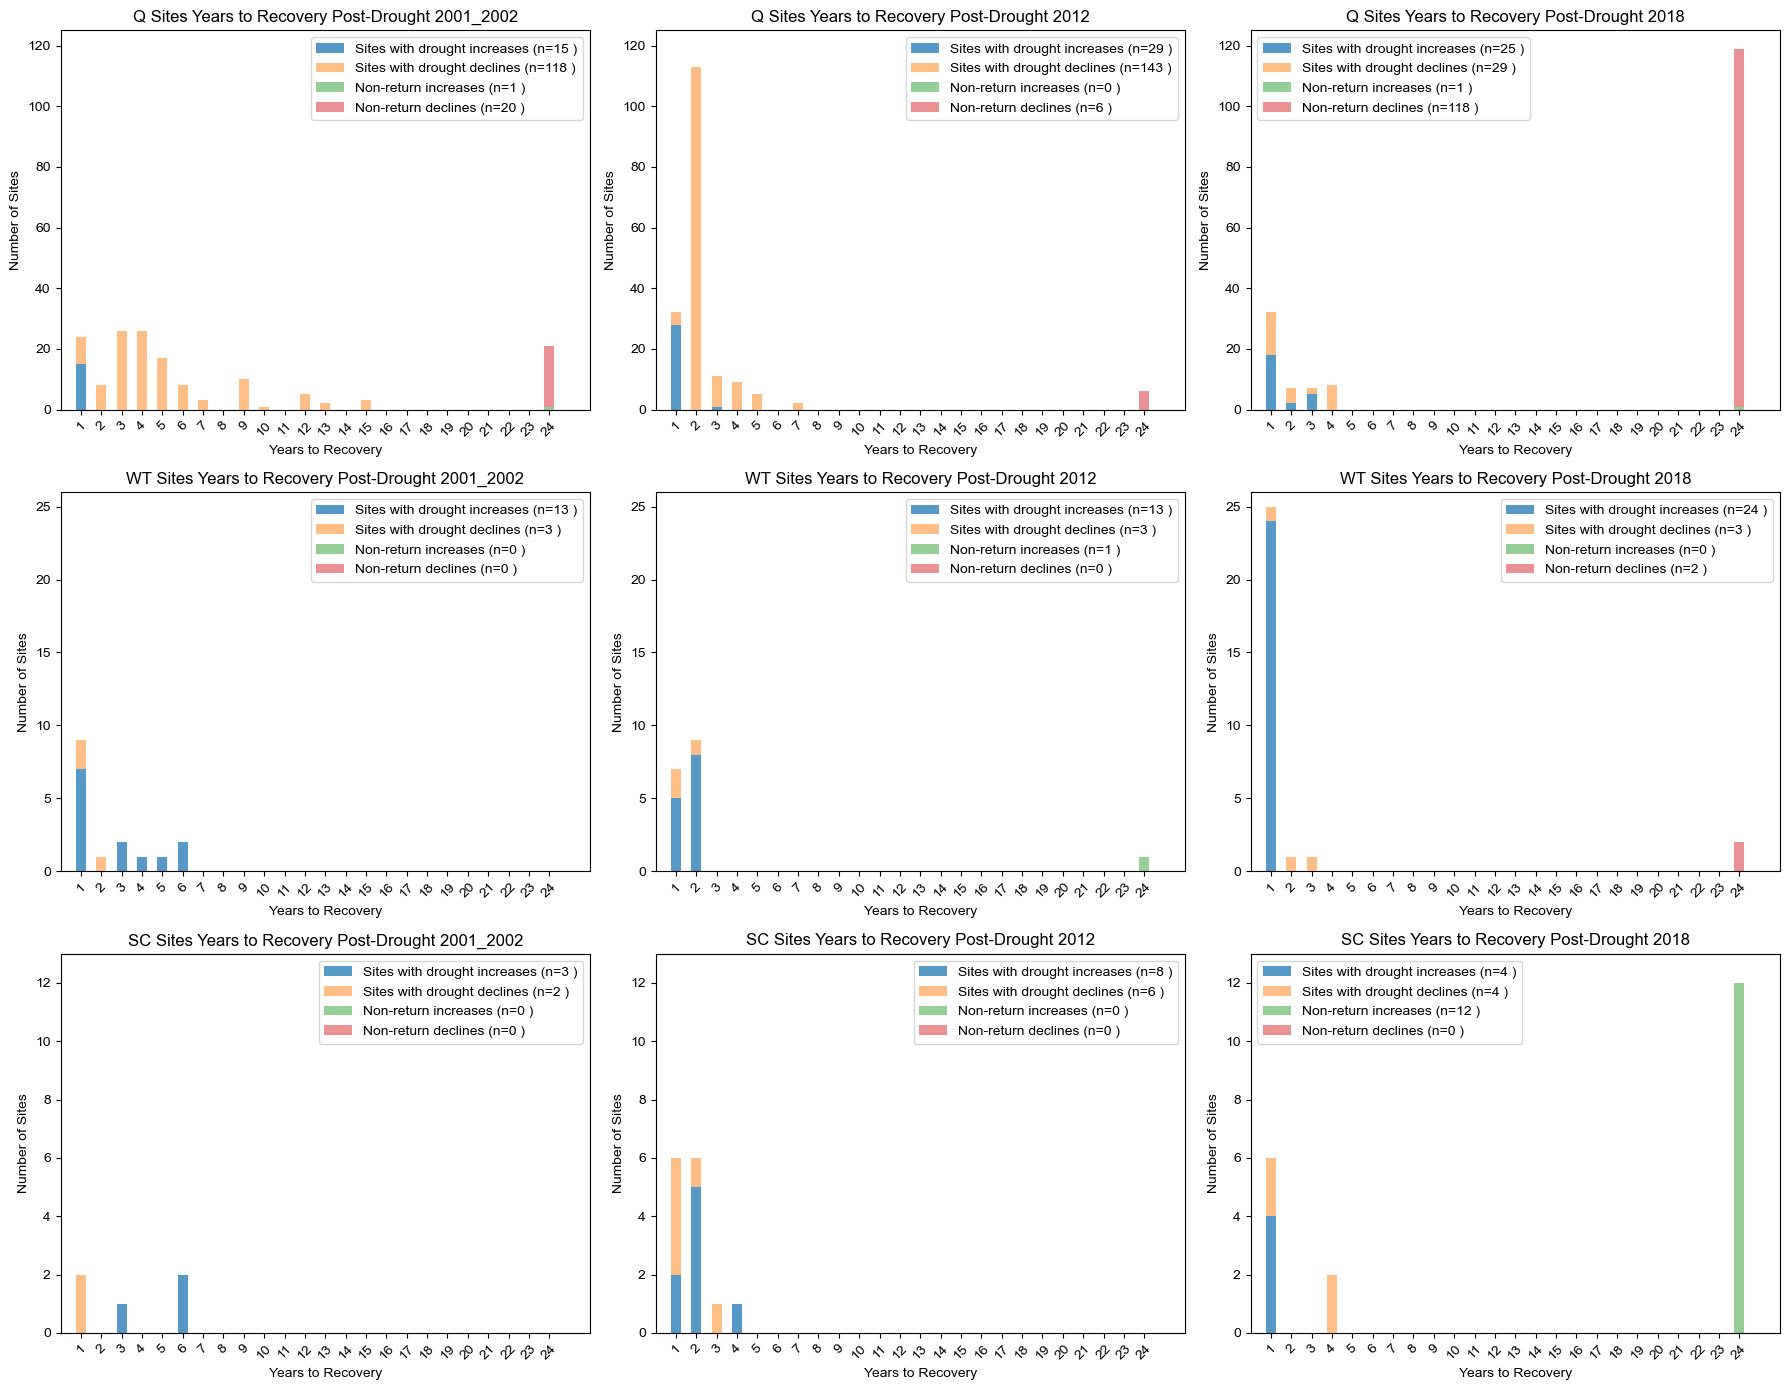

In [42]:
fig, axes = plotting.plot_recovery_years(
    recovery = recovery, 
    var_names = var_names, 
    dr_names = dr_names, 
    fig_dir = fig_dir, save= True)

In [43]:
## Save Data from plot
for var in var_names:
    for dr in dr_names:
        for rc in ['pos', 'neg']:
            r = recovery[var][dr][rc]
            r['recyears_nononrec'].to_csv(
                data_for_figures / f'{var}_recyears_nononrec_{rc}{dr}.csv'
            )
            r['notrecov_nomissing'].to_csv(
                data_for_figures / f'{var}_notrecov_nomissing_{rc}{dr}.csv'
            )

### 8.2 Pre-Post 3 year mean change
SI Table S.5

In [46]:
# Extend annual medians with remaining variables
mk_types    = ['notrend', 'increasing', 'decreasing']

annual_medians = preprocessing.extend_annual_medians(annual_medians, withsites, runoff_efficiency_ann, reservoirs_wyearsdaily, allsites)

# Calculate pre-to-post relative change and filter by MK trend
yearsbefore, yearsafter, prepost_rc, prepost_rc_mk, annual_medians = calculations.calculate_prepost_rel_change(
        var_names, MET_vars, dr_names, dr_years_list, ref_all3,
        annual_medians, sites_all3, mk_trends,
        all_vars_qp, mk_types
    )

RDC
  2001_2002
    notrend      — sites: 184, Rel. Change Post from Pre drought: -31.2292
    increasing   — sites: 3, Rel. Change Post from Pre drought: -30.0000
    decreasing   — sites: 15, Rel. Change Post from Pre drought: -48.9683
  2012
    notrend      — sites: 184, Rel. Change Post from Pre drought: 19.0909
    increasing   — sites: 3, Rel. Change Post from Pre drought: 1.5883
    decreasing   — sites: 15, Rel. Change Post from Pre drought: -25.3676
  2018
    notrend      — sites: 184, Rel. Change Post from Pre drought: -18.0913
    increasing   — sites: 3, Rel. Change Post from Pre drought: -52.3974
    decreasing   — sites: 15, Rel. Change Post from Pre drought: -29.0323
  2020_2021
    notrend      — sites: 184, Rel. Change Post from Pre drought: -19.3598
    increasing   — sites: 3, Rel. Change Post from Pre drought: -36.3526
    decreasing   — sites: 15, Rel. Change Post from Pre drought: -47.9965
WT
  2001_2002
    notrend      — sites: 32, Rel. Change Post from Pre dr

### 8.3a Reference year comparison
Comparing each event to reference period of 2001-2002 event. All reference years for the event (3 yrs pre and post) <br>
SI Table S.6

In [69]:
refMED_rc = calculations.calculate_ref_period_rel_change(all_vars_qp, dr_names, ann_MED, met_ann_MED, annual_medians, ref_all3)

RDC
  # sites in common 2001_2002 and 2012: 143
  Rel. change of 2012 ref. from 2001_2002 ref.: -6.0475
  # sites in common 2001_2002 and 2018: 141
  Rel. change of 2018 ref. from 2001_2002 ref.: -0.3883
  # sites in common 2001_2002 and 2020_2021: 138
  Rel. change of 2020_2021 ref. from 2001_2002 ref.: -12.7898
WT
  # sites in common 2001_2002 and 2012: 14
  Rel. change of 2012 ref. from 2001_2002 ref.: -3.1016
  # sites in common 2001_2002 and 2018: 16
  Rel. change of 2018 ref. from 2001_2002 ref.: 4.5226
  # sites in common 2001_2002 and 2020_2021: 5
  Rel. change of 2020_2021 ref. from 2001_2002 ref.: 0.1117
SC
  # sites in common 2001_2002 and 2012: 3
  Rel. change of 2012 ref. from 2001_2002 ref.: -4.9073
  # sites in common 2001_2002 and 2018: 4
  Rel. change of 2018 ref. from 2001_2002 ref.: -10.8816
  # sites in common 2001_2002 and 2020_2021: 4
  Rel. change of 2020_2021 ref. from 2001_2002 ref.: -1.9402
precip
  Rel. change of 2012 ref. from 2001_2002 ref.: -1.0507
  Rel. 

### 8.3b Pre - Pre baseline assessment
Comparing each event to reference period of 2001-2002 event. Same as 7.3a but only using ref years before drought <br>
Not in manuscript

In [47]:
preMED_rc = calculations.calculate_pre_period_rel_change(all_vars_qp, dr_names, ann_MED, annual_medians, yearsbefore)

RDC
  Rel. change of 2012 pre from 2001_2002 pre: -23.2143
  Rel. change of 2018 pre from 2001_2002 pre: -12.7563
  Rel. change of 2020_2021 pre from 2001_2002 pre: -20.1423
WT
  Rel. change of 2012 pre from 2001_2002 pre: -4.4517
  Rel. change of 2018 pre from 2001_2002 pre: 8.5405
  Rel. change of 2020_2021 pre from 2001_2002 pre: -5.6452
SC
  Rel. change of 2012 pre from 2001_2002 pre: -2.6850
  Rel. change of 2018 pre from 2001_2002 pre: -5.7195
  Rel. change of 2020_2021 pre from 2001_2002 pre: 1.8210
precip
  Rel. change of 2012 pre from 2001_2002 pre: 0.8159
  Rel. change of 2018 pre from 2001_2002 pre: -5.9813
  Rel. change of 2020_2021 pre from 2001_2002 pre: -4.2838
temp
  Rel. change of 2012 pre from 2001_2002 pre: 5.4082
  Rel. change of 2018 pre from 2001_2002 pre: 42.4012
  Rel. change of 2020_2021 pre from 2001_2002 pre: 34.2567
runoff_efficiency
  Rel. change of 2012 pre from 2001_2002 pre: 4.3021
  Rel. change of 2018 pre from 2001_2002 pre: 4.6601
  Rel. change of 202

## 9. OTHER PLOTS

### WT in July vs annual

In [48]:
# prep data, grab WT julys
sorted_WT_ann, sorted_WT_julys = calculations.get_var_onemonth_timeseries(var_all = withsites['WT'].loc[1998:2022], month=7)

Saved figures to /Users/emilynagamoto/PycharmProjects/drought-impacts-updates/UCRB-drought/OUTPUTS/Figures/


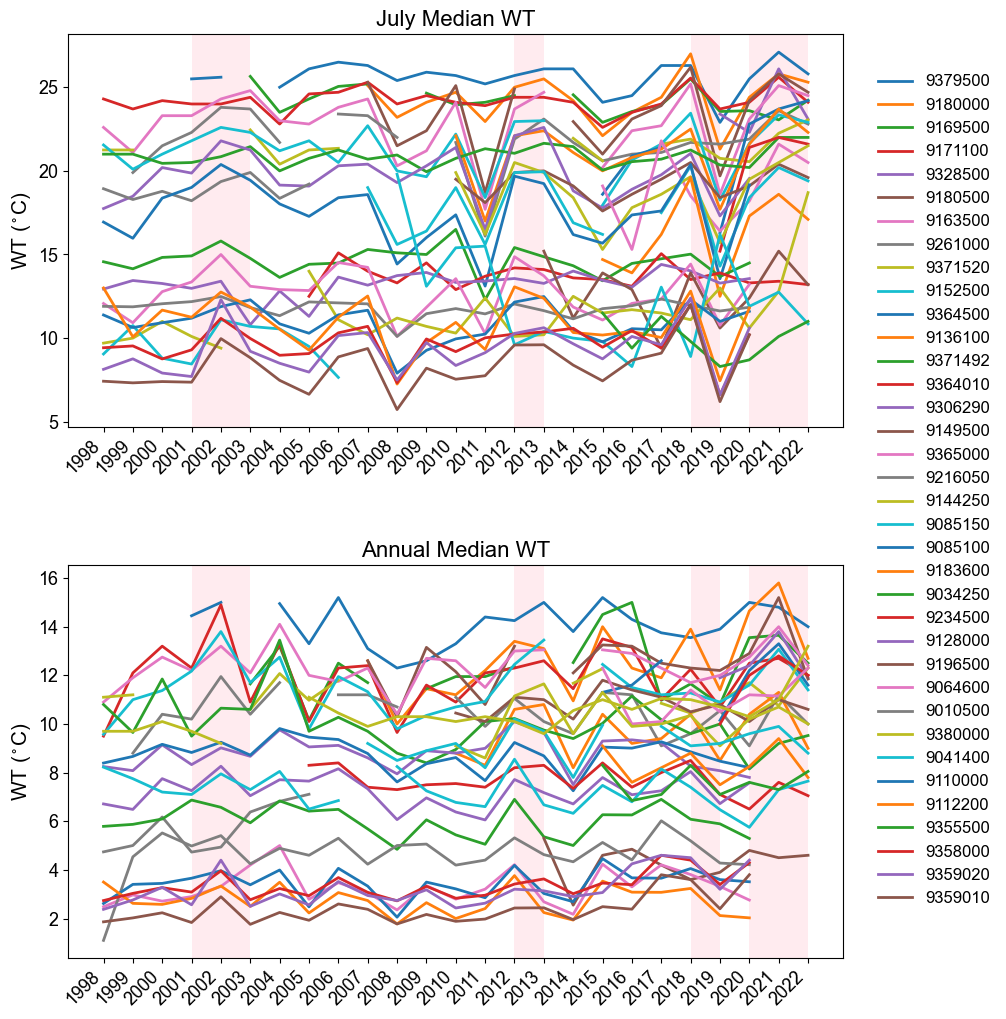

In [49]:
## WT in JULY
fig = plotting.plot_var_month_ann(
    var = var_names[1],
    month = 'July',
    y_label = r'WT ($^\circ$C)',
    sorted_var_month = sorted_WT_julys,
    sorted_var_ann = sorted_WT_ann,
    fig_dir = fig_dir,
    save= True)

In [50]:
# save WT data for July plot
withsites['WT'].loc[1998:2022].to_csv(data_for_figures / 'WT_daily_fordrsites.csv')

### Reservoir storage

Saved figures to /Users/emilynagamoto/PycharmProjects/drought-impacts-updates/UCRB-drought/OUTPUTS/Figures/


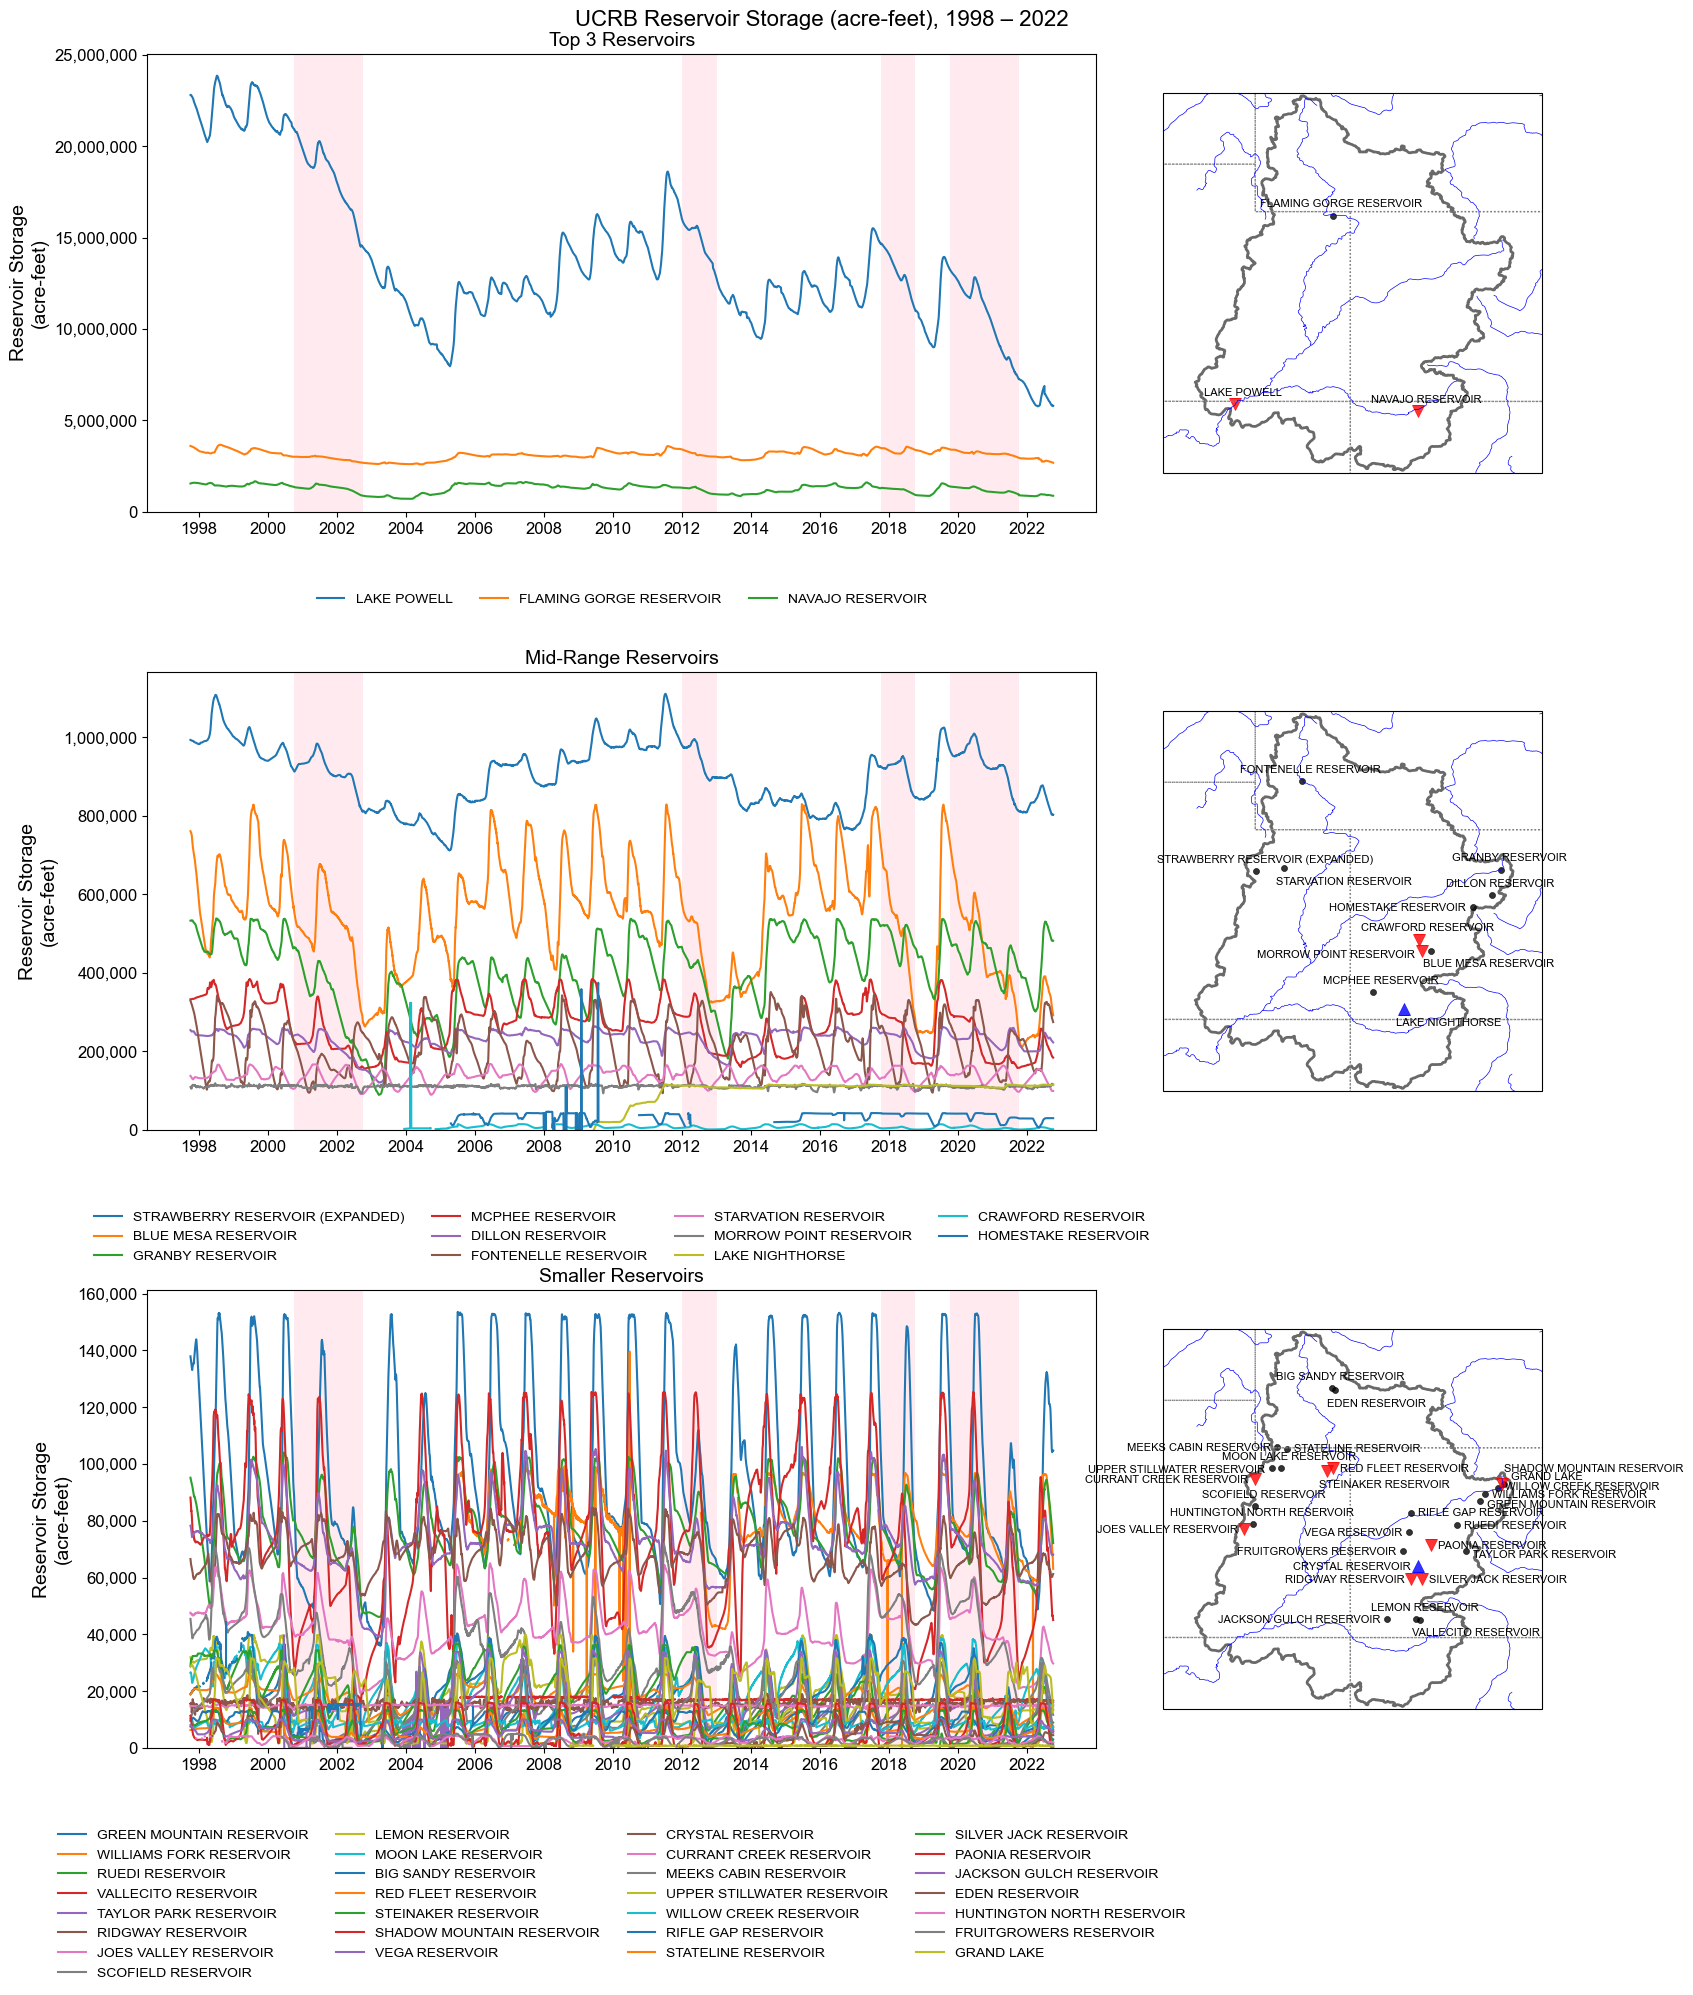

In [51]:
fig,res_partitions, reservoirs_mktrend, label_offsets, drought_periods, mk_styles, row_config, res_names = plotting.plot_reservoir_line_map(reservoirs_metadata, reservoirs_data, mk_trends_reservoirs = mk_trends['reservoirs'],
                           upper_colorado_river_boundary_dir = dirs['upper_colorado_river_boundary_dir'],
                             fig_dir = fig_dir, save = True)

### Reservoir Maps

Saved figures to /Users/emilynagamoto/PycharmProjects/drought-impacts-updates/UCRB-drought/OUTPUTS/Figures/


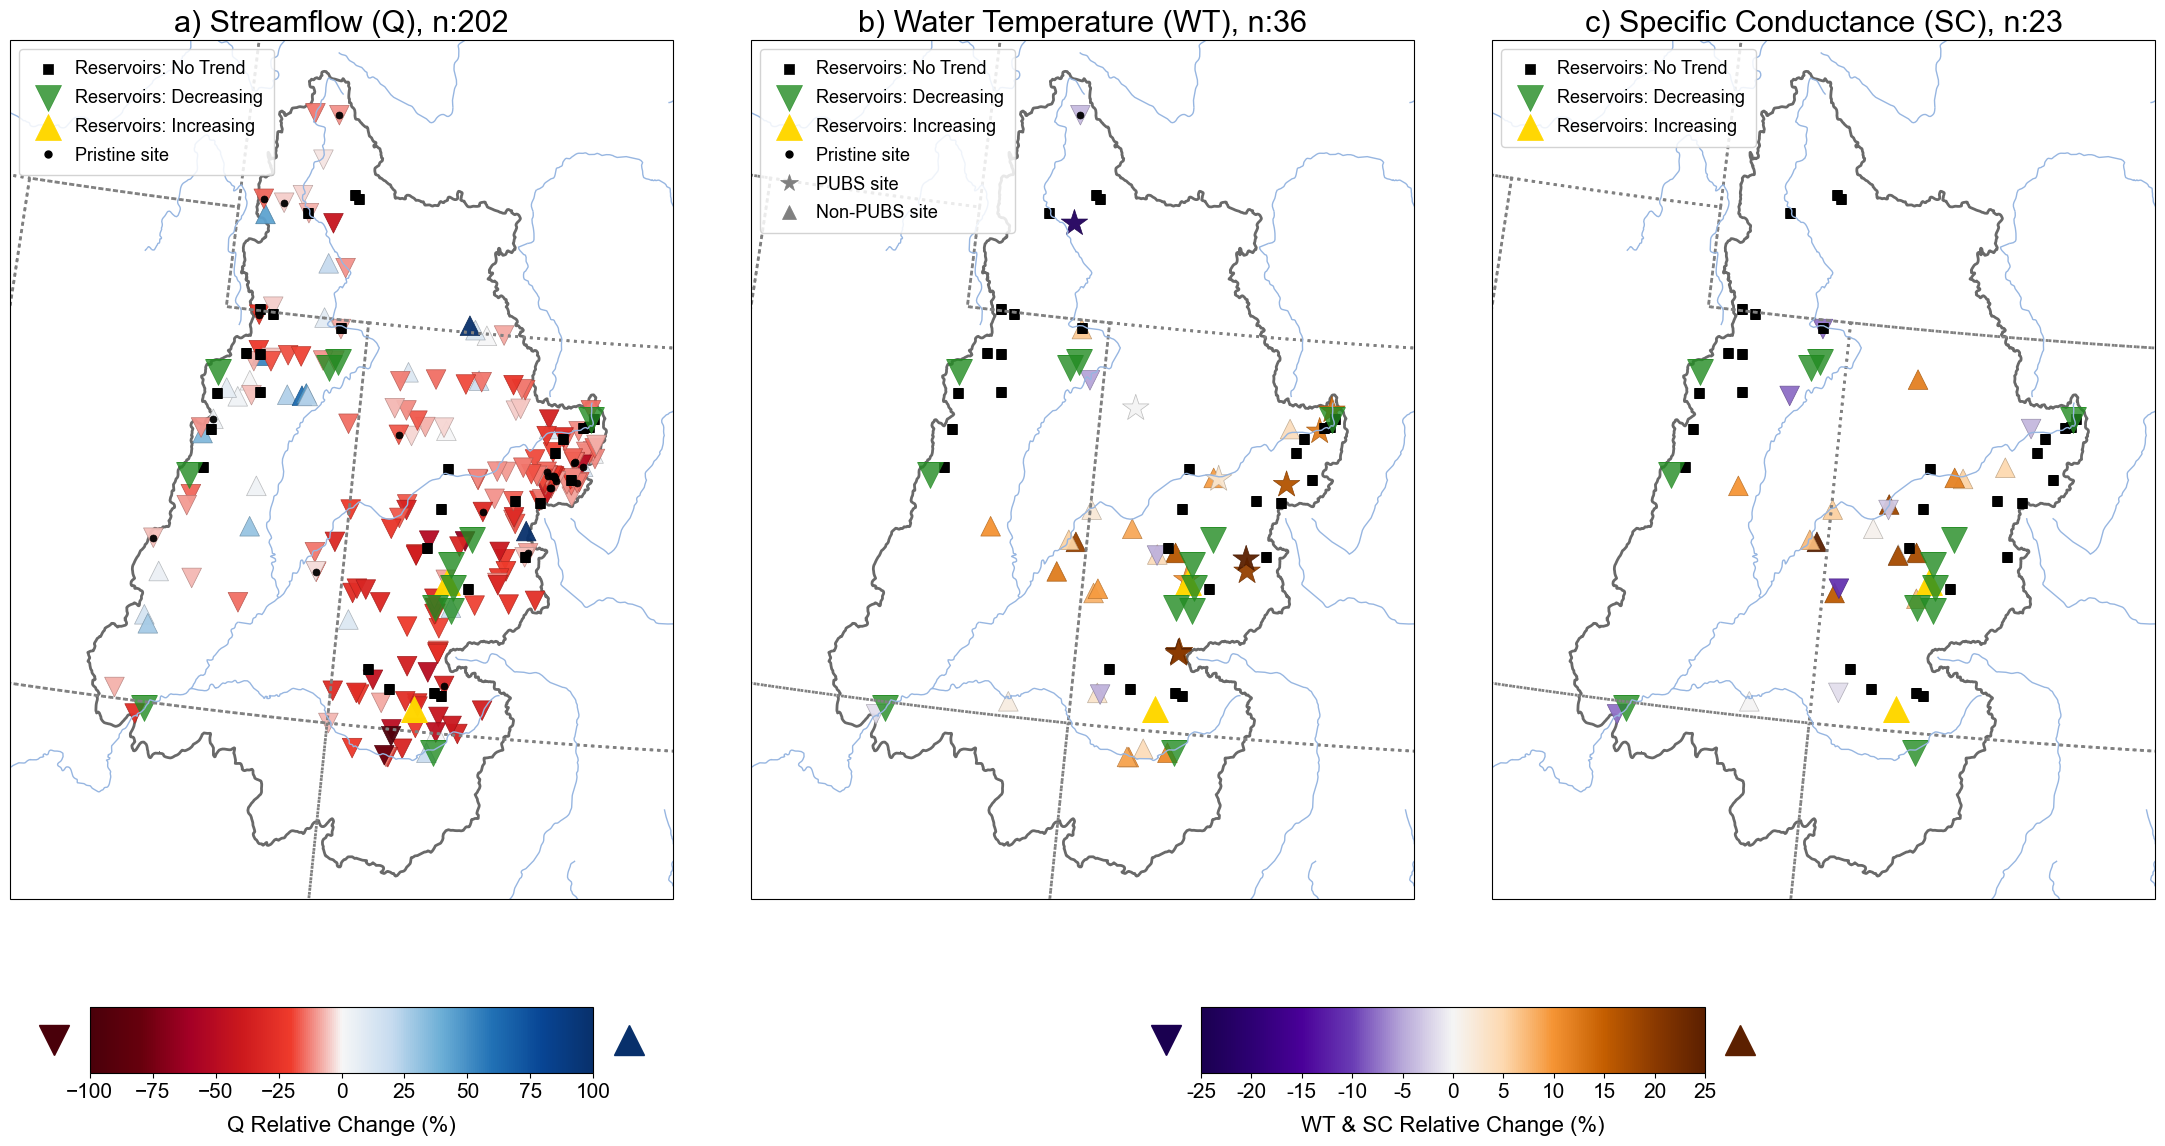

In [52]:
var_settings = {
    var_names[0]: {
        'colorscheme': dark_bwr,'vmin': -100, 'vmax': 100, 'title_label': 'a)', 'plot_name': 'Streamflow (Q)', 'cbar_ticks': None,'cbar_title': 'Q Relative Change (%)',
    },
    var_names[1]: {
        'colorscheme': dark_puor,'vmin': -25, 'vmax': 25,'title_label': 'b)', 'plot_name': 'Water Temperature (WT)','cbar_ticks': np.arange(-25, 30, 5),'cbar_title': 'WT & SC Relative Change (%)',
    },
    var_names[2]: {
        'colorscheme': dark_puor,'vmin': -25, 'vmax': 25, 'title_label': 'c)', 'plot_name': 'Specific Conductance (SC)','cbar_ticks': np.arange(-25, 30, 5),'cbar_title': 'WT & SC Relative Change (%)',
    },
}

fig, map_axes = plotting.plot_relchange_map(
    var_names= var_names,
    MED_relchange_map = list_mapping_return, 
    var_settings = var_settings,
    upper_colorado_river_boundary_dir = dirs['upper_colorado_river_boundary_dir'],
    PUBS_sites_all3=PUBS_sites_all3, 
    wt_var=var_names[1],
    extent=(-113, -105, 35.5, 43.5), 
    reservoirs_mktrend = reservoirs_mktrend,
    fig_dir=fig_dir, 
    save=True)

### SI fig 2 - ann distribution

Saved figures to /Users/emilynagamoto/PycharmProjects/drought-impacts-updates/UCRB-drought/OUTPUTS/Figures/


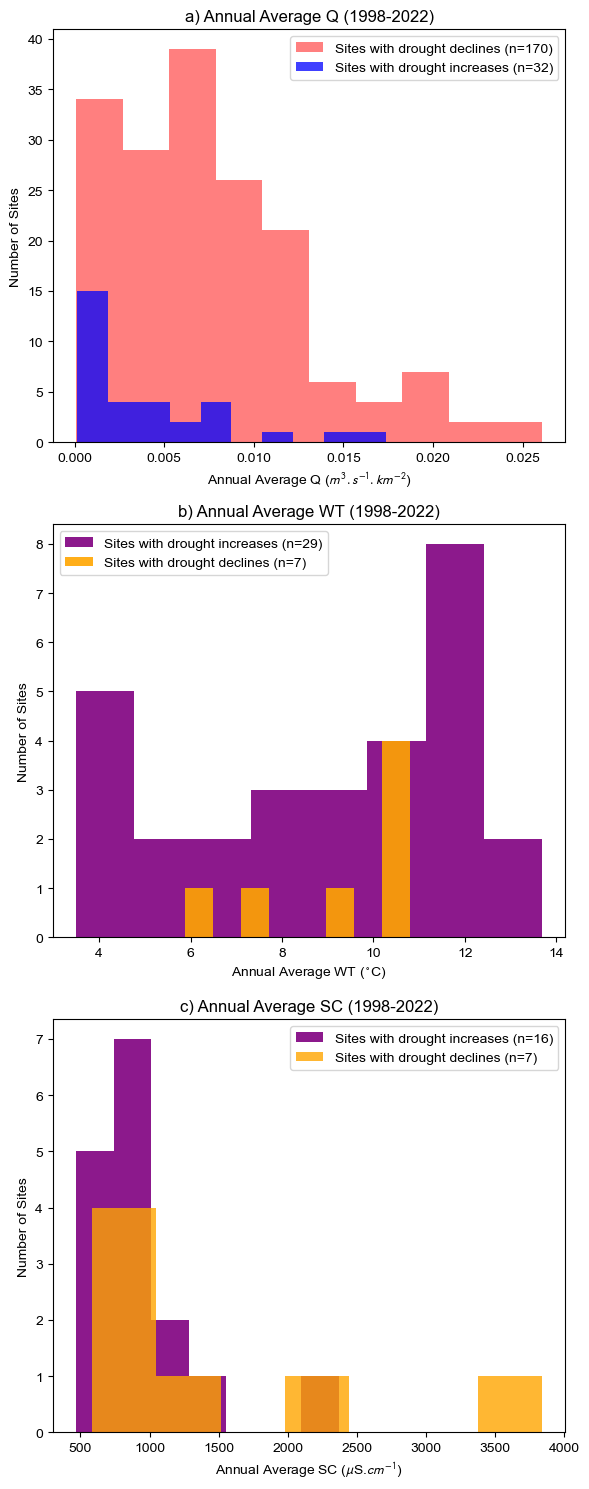

In [53]:
## SI fig 2 - ann distribution
fig, ax = plotting.plot_ann_distribution_for_pos_neg_RelChange(years = years, sites_by_rc =sites_by_rc , var_names = var_names, fig_dir=fig_dir, save=True)

### Graphical Abstract


Saved figures to /Users/emilynagamoto/PycharmProjects/drought-impacts-updates/UCRB-drought/OUTPUTS/Figures/


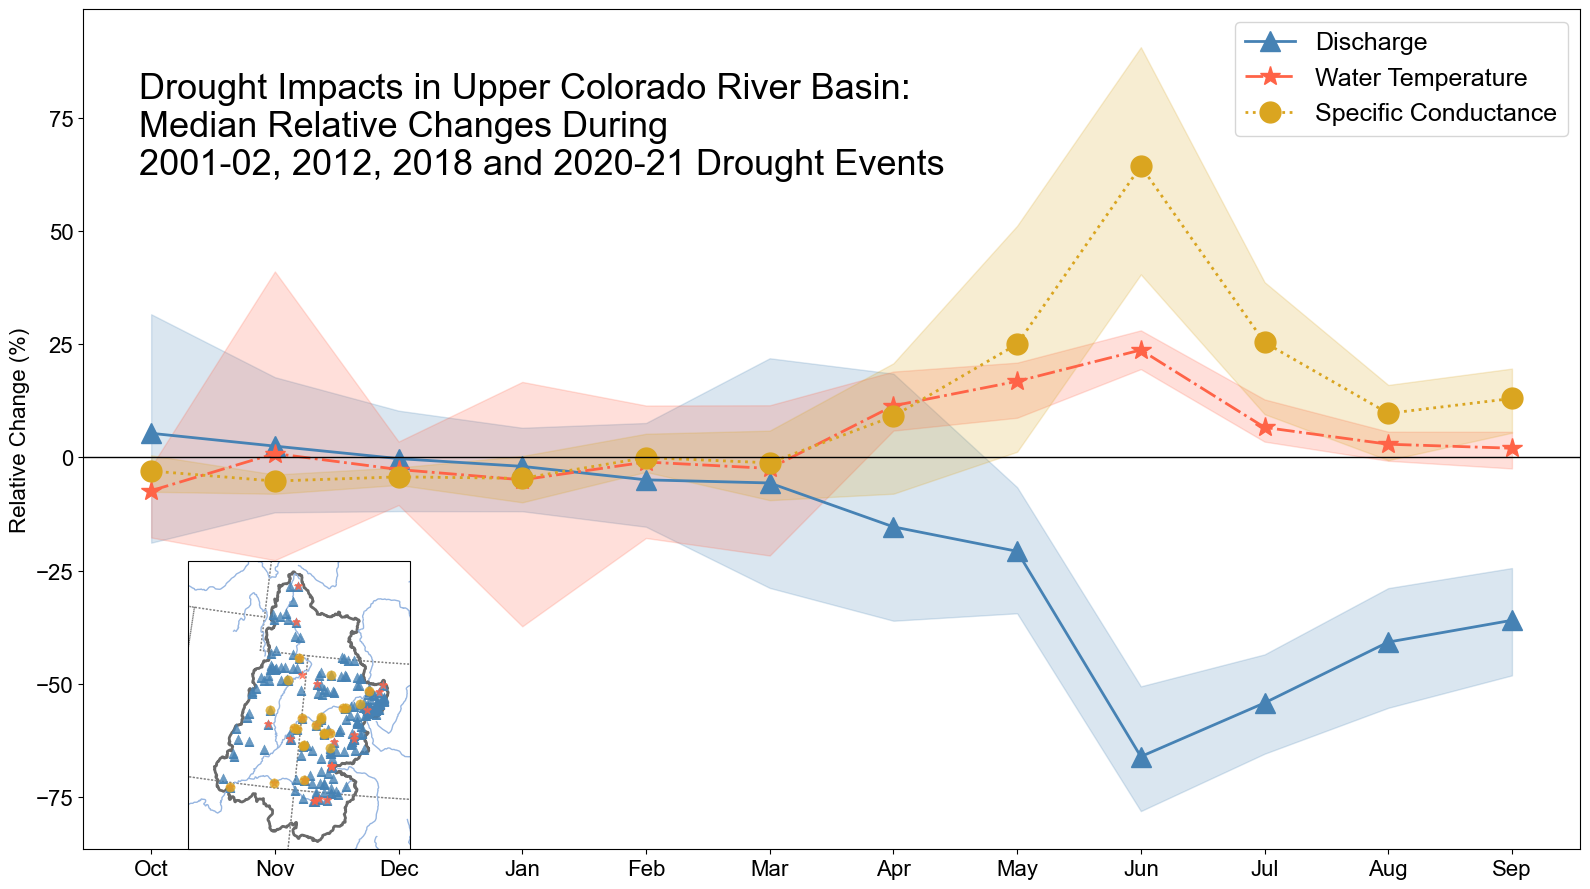

In [112]:
var_colors = {var: c for var, c in zip(var_names, ['steelblue', 'tomato', 'goldenrod'])}
var_rel_names = {'RDC': 'Discharge', 'WT': 'Water Temperature', 'SC': 'Specific Conductance'}

fig, ax, ax2 = plotting.plot_avg_relchange(
    var_names=var_names,
    dr_names=dr_names,
    mon_MED_relchange=mon_MED_relchange,
    MED_relchange_map = list_mapping_return,
    wmon_names=wmon_names,
    var_rel_names=var_rel_names,
    upper_colorado_river_boundary_dir = dirs['upper_colorado_river_boundary_dir'],
    var_colors=var_colors,
    fig_dir=fig_dir,
    save=True
)

## 10. Sensitivity Analysis
This is currently comment out, but if you wanted to see how the Relative Change results would change if you used a different amount of reference years to compare the drought events to, them use this code.

### 10.1) 2 REF years before and after (instead of 3)

In [113]:
# # identify dr and ref years
# dr_years_2,dr_names_2, list_dr_years_2, list_ref_years_2, list_all_years_2 = calculations.identify_years(TRUN_ann_spei_wyears, 
#                                                                                                drought_threshold=-1, 
#                                                                                                reference_threshold=1, window_size=2) ## changed window_size to be 2 

# dr_all3_2, ref_all3_2,dr_years_list_2, sites_all3_2, refyrs_all3_2, dryrs_all3_2 = calculations.build_drought_site_dicts(
#     dr_names_2, list_all_years_2, list_ref_years_2, list_dr_years_2,var_names, list_all_data, avail
# )

Identified 6 drought years: [2001, 2002, 2012, 2018, 2020, 2021]
Grouped into 4 drought events: ['2001_2002', '2012', '2018', '2020_2021']
------ created framework of dictionaries for drought, reference, and all years ------


In [114]:
# allsites_2, all3_all_sites_2, all3vars_2 = calculations.build_site_unions(var_names, dr_names_2, sites_all3_2)
# longtermavg_2, basin_avg_2 = calculations.calculate_longterm_avg(ready, allsites_2, var_names)

Number of sites for each variable across all drought episodes:
RDC: 207
WT: 41
SC: 26
Total unique sites across all variables and episodes: 216
Number of sites with all variables for each drought episode:
2001_2002: 4
2012: 5
2018: 8
2020_2021: 12


In [115]:
# # RDC, WT, SC
# ann_MED_2, mon_MED_2 = calculations.calculate_rel_change_all(
#     var_list      = var_names,
#     dr_names      = dr_names_2,
#     ref_all3      = ref_all3_2,
#     dr_years      = dr_years_2,
#     refyrs_all3   = refyrs_all3_2,
#     dryrs_all3    = dryrs_all3_2,
#     use_presliced = True
# )

# # RDC, WT, SC
# MED_allsites_2, MED_all3_2 = calculations.aggregate_episodes(
#     var_list       = var_names,
#     dr_names       = dr_names_2,
#     ann_MED        = ann_MED_2,
#     include_dr_ref = True
# )

------ calculated annual and monthly median relative change for ['RDC', 'WT', 'SC']  ------
Median Annual Relative Change: RDC [-8.71899239]
Median Annual DR:              RDC [0.0021603]
Median Annual Ref:             RDC [0.00255314]
Median Annual Relative Change: WT [8.58633309]
Median Annual DR:              WT [9.975]
Median Annual Ref:             WT [9.6]
Median Annual Relative Change: SC [-0.73193383]
Median Annual DR:              SC [1018.875]
Median Annual Ref:             SC [942.33333333]


In [116]:
# # RDC, WT, SC
# yespriorSept = False
# seasonMED_2, seasonMED_all_2, allep_seasonal_2, allep_combined_2 = calculations.calculate_seasonal_rel_change(
#     var_list       = var_names,
#     dr_names       = dr_names_2,
#     dr_years       = dr_years_list_2,
#     ref_all3       = ref_all3_2,
#     seasons        = seasons,
#     vartypes       = vartypes,
#     site_index_dict = allsites_2,
#     yespriorSept   = yespriorSept,
#     sites_all3     = sites_all3_2,
#     use_presliced  = True
# )

RDC Median SEASONAL Relative Change:
            dr       ref  relchange
OND  0.002138  0.001986   9.789288
JFM  0.001602  0.001623   1.954898
AMJ  0.006533  0.011168 -31.736919
JAS  0.002562  0.003936 -39.268870
WT Median SEASONAL Relative Change:
             dr        ref  relchange
OND   5.037500   4.725000  14.061822
JFM   2.625000   2.362500  18.390805
AMJ  13.275000  10.325000  19.561243
JAS  18.611634  18.383333   4.896101
SC Median SEASONAL Relative Change:
               dr          ref  relchange
OND  1052.583333  1124.229167  -5.933591
JFM  1114.166667  1166.666667  -3.617723
AMJ   722.583333   539.854167  30.690656
JAS  1014.416667   851.979167  16.330928


In [117]:
# # Flatten drought years across all episodes
# all_dr_years_flat_2 = [yr for episode in list_dr_years_2 for yr in episode]

# MET_sites_all3_2, MET_refyrs_all3_2, MET_dryrs_all3_2 = calculations.build_site_dicts_no_filter(
#             ref_all3_2, dr_names_2, list_all_years_2, list_ref_years_2, list_dr_years_2,
#             MET_vars, list_met_wyears
#         )
# # Calculate climatology and get congruent sites
# basin_avg_met_2, congruent_sites_2, met_avg_list_2 = calculations.calculate_meteorological_climatology(
#     list_met_wyears, all3_all_sites_2, all_dr_years_flat_2, start_year
# )

# # Merge MET basin averages into existing basin_avg dict
# basin_avg_2.update(basin_avg_met_2)

# # Per-episode met averages
# met_avg_2 = {MET: {} for MET in MET_vars}
# for MET in MET_vars:
#     for num, dr in enumerate(dr_names):
#         met_avg_2[MET][dr] = met_avg_list_2[MET][num]

------ created site dictionaries (no availability filtering) ------


In [118]:
# # precip, temp
# met_ann_MED_2, met_mon_MED_2 = calculations.calculate_rel_change_all(
#     var_list      = MET_vars,
#     dr_names      = dr_names_2,
#     ref_all3      = ref_all3_2,
#     dr_years      = dr_years_list_2,
#     data_dict     = congruent_sites_2,
#     use_presliced = False
# )

# # precip, temp
# met_MED_allsites_2, met_MED_all3_2 = calculations.aggregate_episodes(
#     var_list       = MET_vars,
#     dr_names       = dr_names_2,
#     ann_MED        = met_ann_MED_2,
#     include_dr_ref = False
# )

------ calculated annual and monthly median relative change for ['precip', 'temp']  ------
Median Annual Relative Change: precip -24.060532575038923
Median Annual Relative Change: temp 22.859071799600365


In [119]:
# # precip, temp
# met_site_index_2 = {MET: congruent_sites_2[MET].columns for MET in MET_vars}

# met_seasonMED_2, met_seasonMED_all_2, met_allep_seasonal_2, met_allep_combined_2 = calculations.calculate_seasonal_rel_change(
#     var_list        = MET_vars,
#     dr_names        = dr_names_2,
#     dr_years        = dr_years_list_2,
#     ref_all3        = ref_all3_2,
#     seasons         = seasons,
#     vartypes        = vartypes,
#     site_index_dict = met_site_index_2,
#     yespriorSept    = yespriorSept,
#     sites_all3      = MET_sites_all3_2,
#     use_presliced   = True
# )


precip Median SEASONAL Relative Change:
             dr        ref  relchange
OND  46.521959  56.561323 -17.369133
JFM  51.549750  62.670733 -15.710736
AMJ  28.048625  57.741080 -50.685394
JAS  38.699676  49.344873 -24.295962
temp Median SEASONAL Relative Change:
             dr        ref  relchange
OND  -1.962216  -2.298234  -0.501898
JFM  -6.371519  -6.053292  -8.567917
AMJ   7.536912   5.484825  41.318713
JAS  14.440166  14.180826   3.128423


### 10.2) ALL normal years as REF years

In [120]:
# # identify dr and ref years
# dr_years_22,dr_names_22, list_dr_years_22, list_ref_years_22, list_all_years_22 = calculations.identify_years(TRUN_ann_spei_wyears, 
#                                                                                                drought_threshold=-1, 
#                                                                                                reference_threshold=1, window_size=22) ## changed window_size to be 22 

# dr_all3_22, ref_all3_22, dr_years_list_22, sites_all3_22, refyrs_all3_22, dryrs_all3_22 = calculations.build_drought_site_dicts(
#     dr_names_22, list_all_years_22, list_ref_years_22, list_dr_years_22,var_names, list_all_data, avail
# )

Identified 6 drought years: [2001, 2002, 2012, 2018, 2020, 2021]
Grouped into 4 drought events: ['2001_2002', '2012', '2018', '2020_2021']
------ created framework of dictionaries for drought, reference, and all years ------


In [121]:
# allsites_22, all3_all_sites_22, all3vars_22 = calculations.build_site_unions(var_names, dr_names_22, sites_all3_22)
# longtermavg_22, basin_avg_22 = calculations.calculate_longterm_avg(ready, allsites_22, var_names)

Number of sites for each variable across all drought episodes:
RDC: 141
WT: 2
SC: 2
Total unique sites across all variables and episodes: 141
Number of sites with all variables for each drought episode:
2001_2002: 0
2012: 0
2018: 0
2020_2021: 0


In [122]:
# # RDC, WT, SC
# ann_MED_22, mon_MED_22 = calculations.calculate_rel_change_all(
#     var_list      = var_names,
#     dr_names      = dr_names_22,
#     ref_all3      = ref_all3_22,
#     dr_years      = dr_years_22,
#     refyrs_all3   = refyrs_all3_22,
#     dryrs_all3    = dryrs_all3_22,
#     use_presliced = True
# )

# # RDC, WT, SC
# MED_allsites_22, MED_all3_22 = calculations.aggregate_episodes(
#     var_list       = var_names,
#     dr_names       = dr_names_22,
#     ann_MED        = ann_MED_22,
#     include_dr_ref = True
# )

------ calculated annual and monthly median relative change for ['RDC', 'WT', 'SC']  ------
Median Annual Relative Change: RDC [-16.93548387]
Median Annual DR:              RDC [0.00241688]
Median Annual Ref:             RDC [0.0028854]
Median Annual Relative Change: WT [1.08333333]
Median Annual DR:              WT [11.165625]
Median Annual Ref:             WT [11.]
Median Annual Relative Change: SC [-3.9908246]
Median Annual DR:              SC [708.82291667]
Median Annual Ref:             SC [733.]


In [123]:
# # RDC, WT, SC
# yespriorSept = False
# seasonMED_22, seasonMED_all_22, allep_seasonal_22, allep_combined_22 = calculations.calculate_seasonal_rel_change(
#     var_list       = var_names,
#     dr_names       = dr_names_22,
#     dr_years       = dr_years_list_22,
#     ref_all3       = ref_all3_22,
#     seasons        = seasons,
#     vartypes       = vartypes,
#     site_index_dict = allsites_22,
#     yespriorSept   = yespriorSept,
#     sites_all3     = sites_all3_22,
#     use_presliced  = True
# )

RDC Median SEASONAL Relative Change:
            dr       ref  relchange
OND  0.002404  0.002341   0.460526
JFM  0.001737  0.001931  -5.882353
AMJ  0.006554  0.010633 -33.364428
JAS  0.002618  0.003831 -40.298354
WT Median SEASONAL Relative Change:
             dr     ref  relchange
OND   3.693750   3.925  -7.504855
JFM   1.817187   2.050 -18.886223
AMJ  16.534375  15.075   9.445182
JAS  21.115625  21.100  -0.025310
SC Median SEASONAL Relative Change:
              dr     ref  relchange
OND  714.531250  791.00  -9.878242
JFM  695.447917  723.50  -4.172885
AMJ  664.145833  551.75  23.782741
JAS  746.062500  748.75  -1.371329


In [124]:
# # Flatten drought years across all episodes
# all_dr_years_flat_22 = [yr for episode in list_dr_years_22 for yr in episode]

# MET_sites_all3_22, MET_refyrs_all3_22, MET_dryrs_all3_22 = calculations.build_site_dicts_no_filter(
#             ref_all3_22, dr_names_22, list_all_years_22, list_ref_years_22, list_dr_years_22,
#             MET_vars, list_met_wyears
#         )
# # Calculate climatology and get congruent sites
# basin_avg_met_22, congruent_sites_22, met_avg_list_22 = calculations.calculate_meteorological_climatology(
#     list_met_wyears, all3_all_sites_22, all_dr_years_flat_22, start_year
# )

# # Merge MET basin averages into existing basin_avg dict
# basin_avg_22.update(basin_avg_met_22)

# # Per-episode met averages
# met_avg_22 = {MET: {} for MET in MET_vars}
# for MET in MET_vars:
#     for num, dr in enumerate(dr_names):
#         met_avg_22[MET][dr] = met_avg_list_22[MET][num]

------ created site dictionaries (no availability filtering) ------


In [125]:
# # precip, temp
# met_ann_MED_22, met_mon_MED_22 = calculations.calculate_rel_change_all(
#     var_list      = MET_vars,
#     dr_names      = dr_names_22,
#     ref_all3      = ref_all3_22,
#     dr_years      = dr_years_list_22,
#     data_dict     = congruent_sites_22,
#     use_presliced = False
# )

# # precip, temp
# met_MED_allsites_22, met_MED_all3_22 = calculations.aggregate_episodes(
#     var_list       = MET_vars,
#     dr_names       = dr_names_22,
#     ann_MED        = met_ann_MED_22,
#     include_dr_ref = False
# )

------ calculated annual and monthly median relative change for ['precip', 'temp']  ------
Median Annual Relative Change: precip -24.113704042280027
Median Annual Relative Change: temp 32.080740087915935


In [126]:
# # precip, temp
# met_site_index_22 = {MET: congruent_sites_22[MET].columns for MET in MET_vars}

# met_seasonMED_22, met_seasonMED_all_22, met_allep_seasonal_22, met_allep_combined_22 = calculations.calculate_seasonal_rel_change(
#     var_list        = MET_vars,
#     dr_names        = dr_names_22,
#     dr_years        = dr_years_list_22,
#     ref_all3        = ref_all3_22,
#     seasons         = seasons,
#     vartypes        = vartypes,
#     site_index_dict = met_site_index_22,
#     yespriorSept    = yespriorSept,
#     sites_all3      = MET_sites_all3_22,
#     use_presliced   = True
# )


precip Median SEASONAL Relative Change:
             dr        ref  relchange
OND  45.614448  55.160810 -17.831662
JFM  50.220036  57.400930 -15.178982
AMJ  28.067202  56.505195 -50.166202
JAS  39.261317  52.588111 -27.775280
temp Median SEASONAL Relative Change:
             dr        ref  relchange
OND  -1.967717  -2.267007   8.710667
JFM  -6.514088  -5.689240  -8.934623
AMJ   7.512931   5.942698  25.965722
JAS  14.371626  13.767045   5.204331
